This is notbook used to train a recommndation similar tv shows used in media logger app

# set up

In [ ]:
!pip install tensorflow

In [9]:
# import all required lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from collections import Counter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

import pickle


In [2]:
# lets read the data from out json file in to a data frame
tv_show_df = pd.read_json("tv-show.json")

In [3]:
tv_show_df.head(10)

,_id,title,description,averageRating,genre,releaseDate,cast,directors,languages,posterUrl,...,totalSeasons,totalEpisodes,ageRating,youtubeVideoId,tmdbId,imdbId,createdAt,updatedAt,__v,avgRunTime
0,68e2760f50d507e43af606db,Alice in Borderland,"With his two friends, a video-game-obsessed yo...",8.2,"[Mystery, Drama, Action]",2020-12-10T00:00:00.000Z,"[Kento Yamazaki, Tao Tsuchiya, Kotaro Daigo]",[],[japanese],https://image.tmdb.org/t/p/w500/Ac8ruycRXzgcsn...,...,3,22,18.0,EEJ7nUvXUYA,110316,tt10795658,2025-10-05T13:43:43.525Z,2025-10-05T13:43:43.525Z,0,NaN
1,68e2783d6167e55d69eddf59,Peacemaker,"The continuing story of Peacemaker, a vainglor...",8.2,"[Action, Fantasy, Drama]",2022-01-13T00:00:00.000Z,"[John Cena, Danielle Brooks, Freddie Stroma, J...",[James Gunn],[english],https://image.tmdb.org/t/p/w500/yb4F1Oocq8GfQt...,...,2,16,17.0,O9DAiLI7Cn8,110492,tt13146488,2025-10-05T13:53:01.467Z,2025-10-05T13:53:01.467Z,0,NaN
2,68e2813a5df69ce8e15fb6a9,Kaiju No. 8,In a world plagued by creatures known as Kaiju...,8.5,"[Animation, Action, Fantasy]",2024-04-13T00:00:00.000Z,"[Masaya Fukunishi, Asami Seto, Wataru Katoh, F...",[],[japanese],https://image.tmdb.org/t/p/w500/bJxGs0w5RAhaX4...,...,1,23,14.0,FsAKMsUjaK0,207468,tt21975436,2025-10-05T14:31:22.972Z,2025-10-05T14:31:22.972Z,0,24.0
3,68e2813b5df69ce8e15fb6db,Prison Break,"Due to a political conspiracy, an innocent man...",8.1,"[Action, Crime, Drama]",2005-08-29T00:00:00.000Z,"[Wentworth Miller, Dominic Purcell, Sarah Wayn...",[Paul T. Scheuring],[english],https://image.tmdb.org/t/p/w500/z885tJn5kkUHpp...,...,5,88,0.0,AL9zLctDJaU,2288,tt0455275,2025-10-05T14:31:23.731Z,2025-10-05T14:31:23.731Z,0,45.0
4,68e2813e5df69ce8e15fb797,Family Guy,"Sick, twisted, politically incorrect and Freak...",7.4,"[Animation, Comedy]",1999-01-31T00:00:00.000Z,"[Seth MacFarlane, Alex Borstein, Mila Kunis, S...",[Seth MacFarlane],[english],https://image.tmdb.org/t/p/w500/8o8kiBkWFK3gVy...,...,23,441,16.0,J32iwo65RMc,1434,tt0182576,2025-10-05T14:31:26.107Z,2025-10-05T14:31:26.107Z,0,22.0
5,68e2814b5df69ce8e15fbb39,Gen V,"At America's only college for superheroes, gif...",7.7,"[Action, Drama, Fantasy]",2023-09-28T00:00:00.000Z,"[Jaz Sinclair, Lizze Broadway, Maddie Phillips...","[Craig Rosenberg, Evan Goldberg, Eric Kripke]",[english],https://image.tmdb.org/t/p/w500/tEv842Nd5uMSav...,...,2,16,17.0,uhjJ5brX-bY,205715,tt13159924,2025-10-05T14:31:39.923Z,2025-10-05T14:31:39.923Z,0,NaN
6,68e2814c5df69ce8e15fbb5f,House,"Dr. Gregory House, a drug-addicted, unconventi...",8.6,"[Drama, Mystery, Comedy]",2004-11-16T00:00:00.000Z,"[Hugh Laurie, Robert Sean Leonard, Omar Epps, ...",[David Shore],[english],https://image.tmdb.org/t/p/w500/3Cz7ySOQJmqiuT...,...,8,176,0.0,MczMB8nU1sY,1408,tt0412142,2025-10-05T14:31:40.391Z,2025-10-05T14:31:40.391Z,0,44.0
7,68e281515df69ce8e15fbcd1,FROM,Unravel the mystery of a nightmarish town in m...,8.2,"[Mystery, Drama, Fantasy]",2022-02-20T00:00:00.000Z,"[Harold Perrineau, Catalina Sandino Moreno, Ei...",[John Griffin],[english],https://image.tmdb.org/t/p/w500/cjXLrg4R7FRPFa...,...,4,30,17.0,pDHqAj4eJcM,124364,tt9813792,2025-10-05T14:31:45.128Z,2025-10-05T14:31:45.128Z,0,NaN
8,68e281525df69ce8e15fbd17,"Bon Appétit, Your Majesty","After time traveling to the Joseon era, a tale...",8.8,"[Fantasy, Drama]",2025-08-23T00:00:00.000Z,"[Yoona, Lee Chae-min, Kang Hanna, Choi Gwi-hwa...",[Jang Tae-yoo],"[korean, mandarin]",https://image.tmdb.org/t/p/w500/xnDFKpPeANnUaR...,...,1,12,13.0,rkB623sLOiM,280945,tt37600136,2025-10-05T14:31:46.082Z,2025-10-05T14:31:46.082Z,0,80.0
9,68e281525df69ce8e15fbd33,The Blacklist,"Raymond ""Red"" Reddington, one of the FBI's mos...",7.6,"[Drama, Crime, Mystery]",2013-09-23T00:00:00.000Z,"[James Spader, Diego Klattenhoff, Hisham Tawfi...",[Jon Bokenkamp],[english],https://image.tmdb.org/t/p/w500/4HTfd1PhgFUenJ...,...,10,218,0.0,JGBIimq1I3A,46952,tt2741602,2025-10-05T14:31:46.430Z,2025-10-05T14:31:46.430Z,0,NaN


# **Data processing**

In [67]:
tv_show_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   _id             51 non-null     object             
 1   title           51 non-null     object             
 2   description     51 non-null     object             
 3   averageRating   51 non-null     float64            
 4   genre           51 non-null     object             
 5   releaseDate     51 non-null     datetime64[ns, UTC]
 6   cast            51 non-null     object             
 7   directors       51 non-null     object             
 8   languages       51 non-null     object             
 9   posterUrl       51 non-null     object             
 10  backdropUrl     51 non-null     object             
 11  isActive        51 non-null     bool               
 12  status          51 non-null     object             
 13  tags            51 non-null     objec

lets convert the date to datetime

In [68]:
tv_show_df["releaseDate"] = pd.to_datetime(tv_show_df["releaseDate"] , errors="coerce")
tv_show_df["createdAt"] = pd.to_datetime(tv_show_df["createdAt"] , errors="coerce")
tv_show_df["updatedAt"] = pd.to_datetime(tv_show_df["updatedAt"] , errors="coerce")

tv_show_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   _id             51 non-null     object             
 1   title           51 non-null     object             
 2   description     51 non-null     object             
 3   averageRating   51 non-null     float64            
 4   genre           51 non-null     object             
 5   releaseDate     51 non-null     datetime64[ns, UTC]
 6   cast            51 non-null     object             
 7   directors       51 non-null     object             
 8   languages       51 non-null     object             
 9   posterUrl       51 non-null     object             
 10  backdropUrl     51 non-null     object             
 11  isActive        51 non-null     bool               
 12  status          51 non-null     object             
 13  tags            51 non-null     objec

# **Visualization**

## Distribution

lets focus on plotting distribution of all the numeric values


In [ ]:
num_columns = tv_show_df.select_dtypes(include='number')
num_columns.columns

Index(['averageRating', 'totalSeasons', 'totalEpisodes', 'ageRating', 'tmdbId',
       '__v', 'avgRunTime'],
      dtype='object')

### Age Rating

Text(0.5, 1.0, 'Age rating vs count')

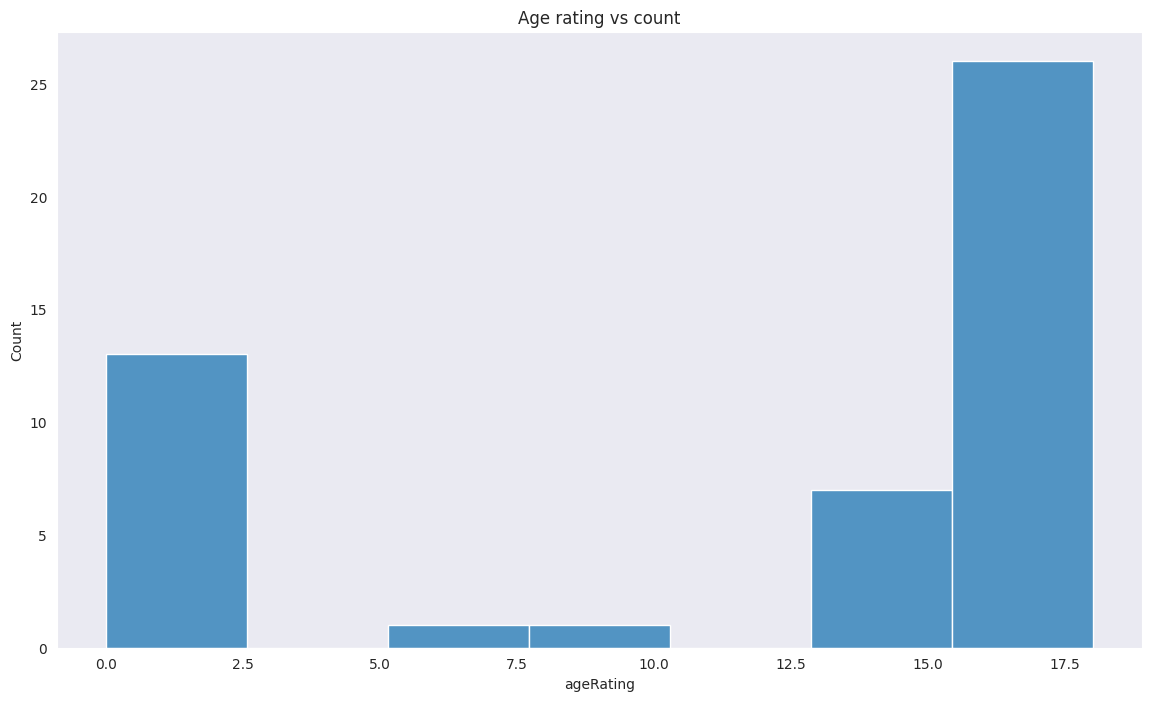

In [ ]:
# lets have a hist plot of age rating against count
sns.set_style("dark");
plt.figure(figsize=(14, 8));

sns.histplot(x = "ageRating" , data=tv_show_df)
plt.title('Age rating vs count')

Text(0.5, 1.0, 'Age rating vs count')

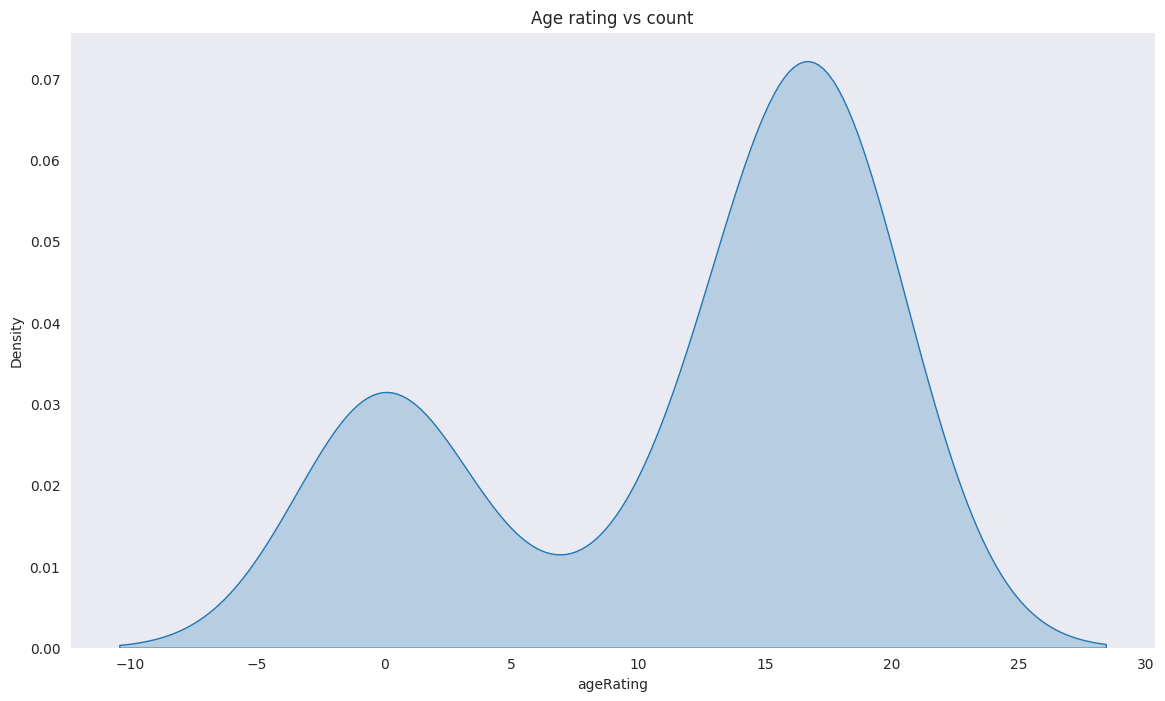

In [ ]:
#kde plot
plt.figure(figsize=(14, 8));

sns.kdeplot(x = "ageRating" , data=tv_show_df , fill=True)
plt.title('Age rating vs count')

<Axes: title={'center': 'Age rating vs count'}, xlabel='ageRating', ylabel='count'>

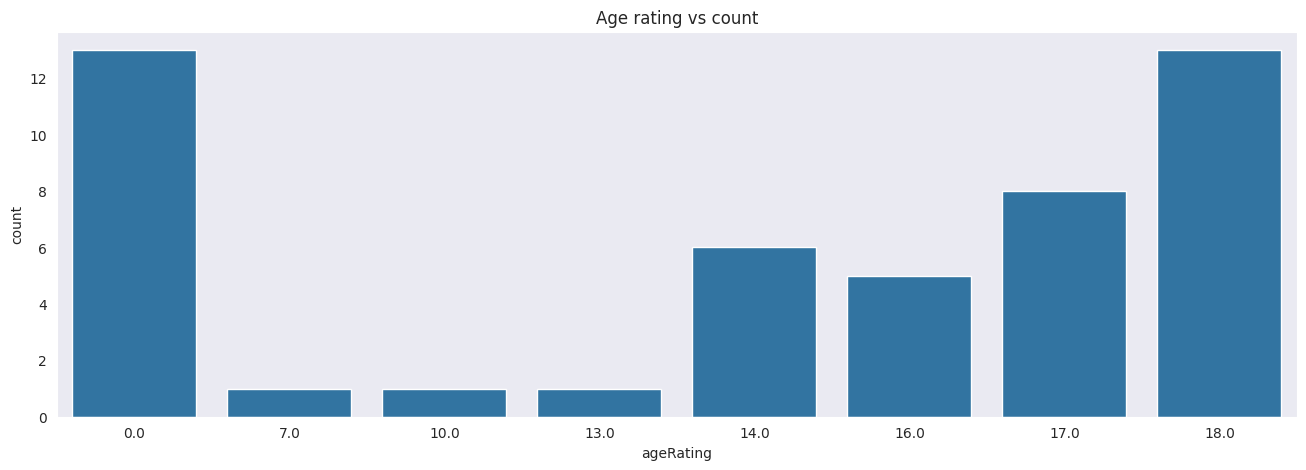

In [ ]:
# count plot
plt.figure(figsize=(16 , 5));
plt.title("Age rating vs count")
sns.countplot( x = "ageRating" , data = tv_show_df)

<Axes: title={'center': 'age rating box plot'}, xlabel='ageRating'>

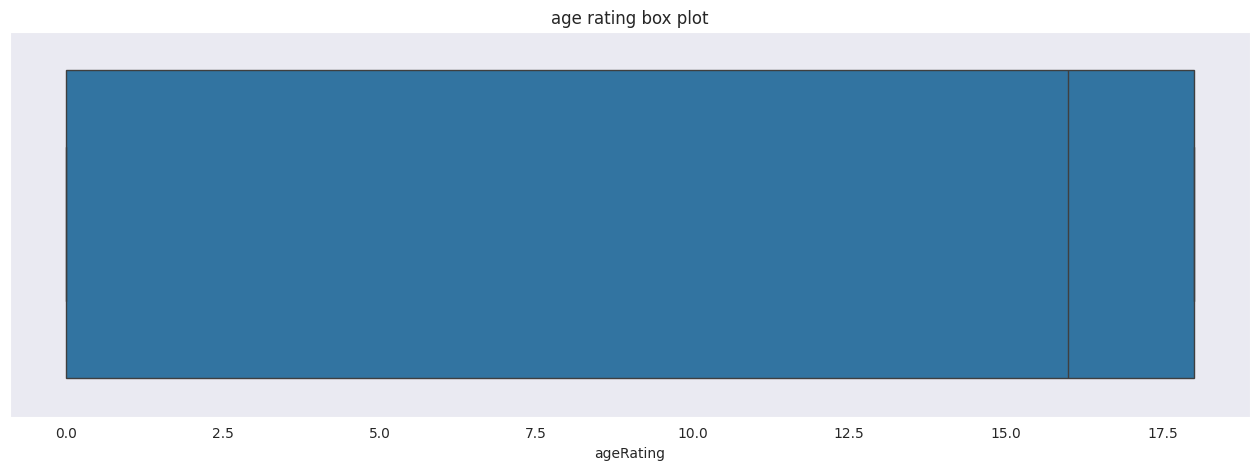

In [ ]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("age rating box plot")
sns.boxplot(x=tv_show_df["ageRating"])

majority in range of 15 to 20 , the initial 0 values are also taken as nan or unrated .will has to be imputed for training.

### **Average rating**

Text(0.5, 1.0, 'Average rating vs count')

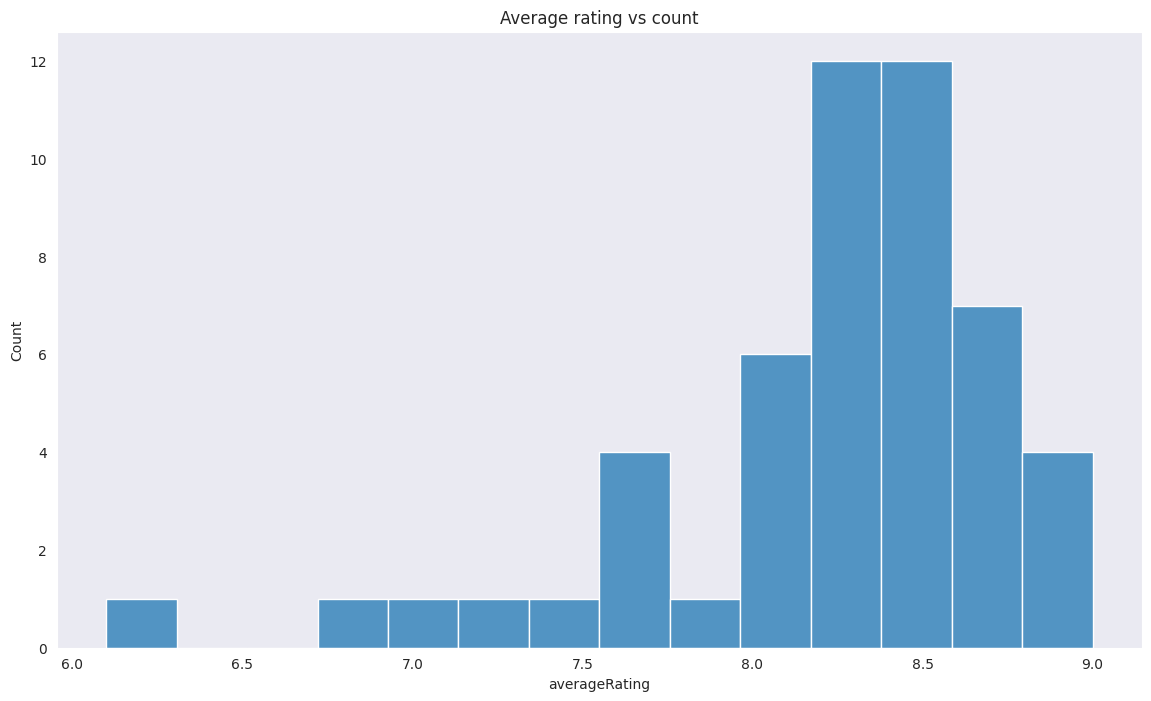

In [ ]:
# lets focus on count vs the plot of average rating
plt.figure(figsize=(14, 8));

sns.histplot(x ="averageRating", data = tv_show_df);
plt.title("Average rating vs count")

Text(0.5, 1.0, 'Average rating vs count')

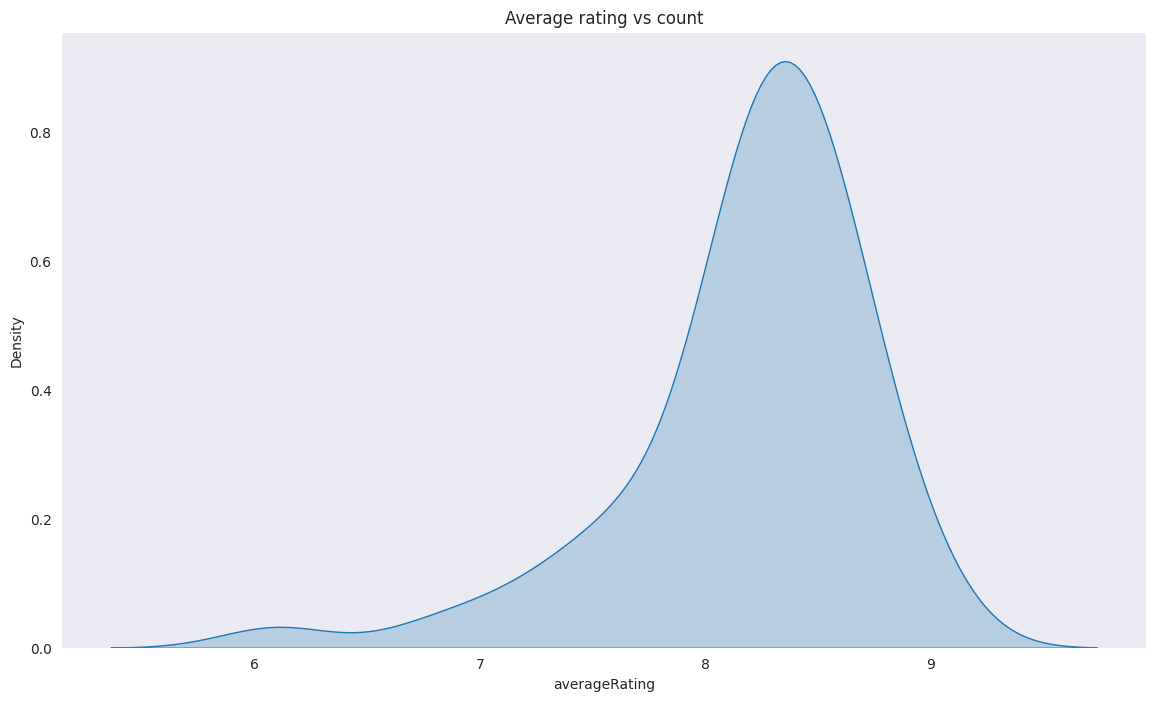

In [ ]:
# lets draw the kde plot
plt.figure(figsize=(14, 8));

sns.kdeplot(x ="averageRating", data = tv_show_df , fill =True);
plt.title("Average rating vs count")

we can see the peak at 8.5 range and majority of our data lie in 7.5 to 8.5

<Axes: title={'center': 'average rating box plot'}, xlabel='averageRating'>

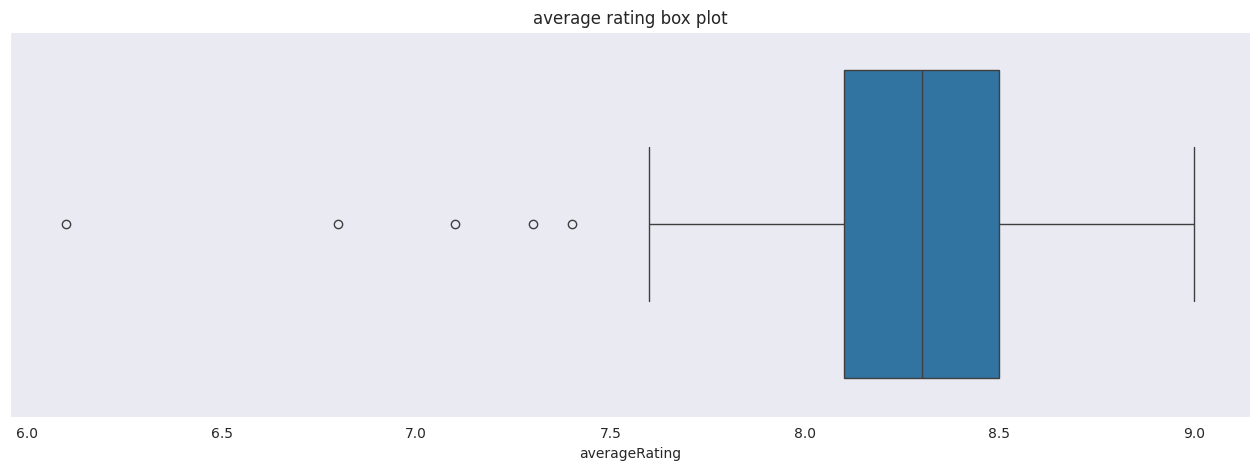

In [ ]:
# let drawe the box plot these should not be out liers since we have a limt of 0-10
plt.figure(figsize=(16 , 5));
plt.title("average rating box plot")
sns.boxplot(x=tv_show_df["averageRating"])

we can see out liers here duee to the small data set we have . we will not be imputing this values since they serve important information

### created at

<Axes: title={'center': 'created at vs count'}, xlabel='createdAt', ylabel='Count'>

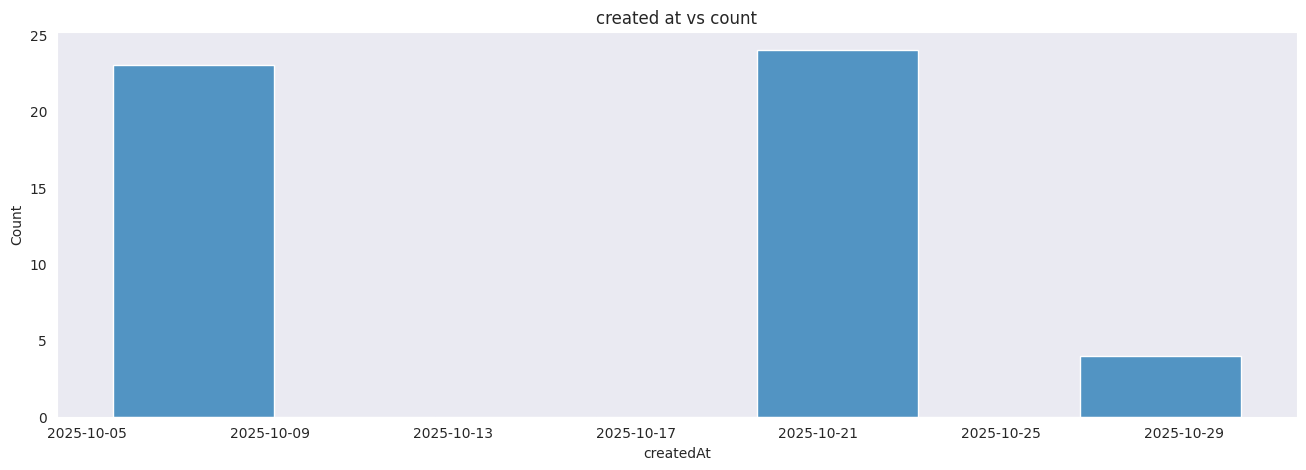

In [ ]:
# hist graph of count vs created at time
sns.set_style("dark");
plt.figure(figsize=(16 , 5));

plt.title("created at vs count")
sns.histplot( x = "createdAt" , data = tv_show_df)

Text(0.5, 1.0, 'created at vs count')

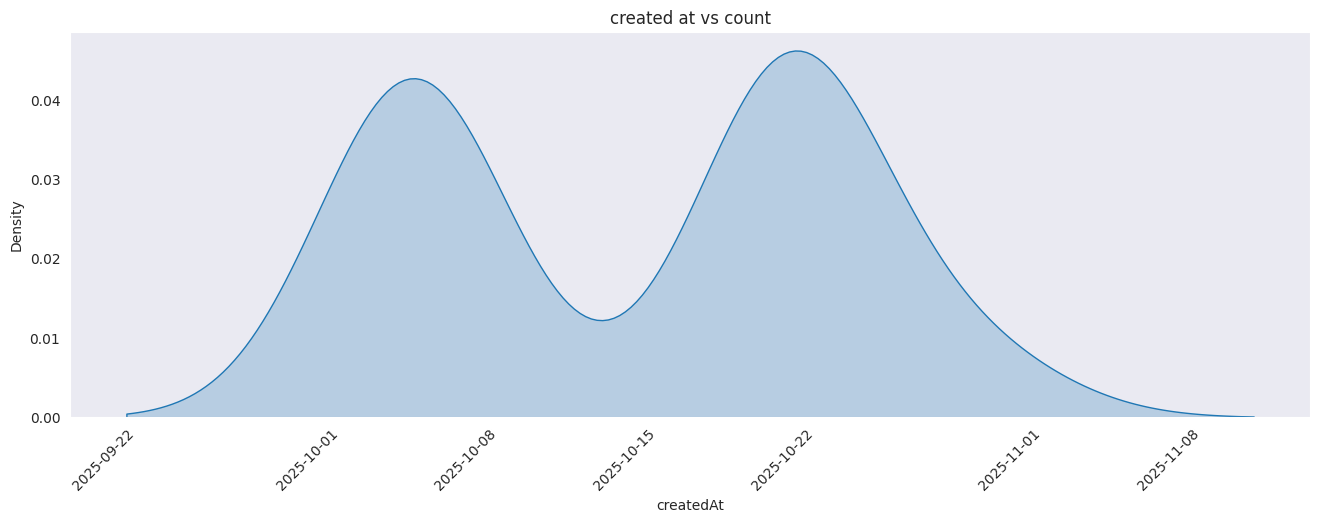

In [ ]:
# create a kde chat
plt.figure(figsize=(16 , 5));
sns.kdeplot(x = "createdAt" , data = tv_show_df , fill = True)
plt.xticks(rotation=45)
plt.title("created at vs count")

this dont really make much relational information so we will not include this in training

### **Release date**

<Axes: title={'center': 'release date  vs count'}, xlabel='releaseDate', ylabel='Count'>

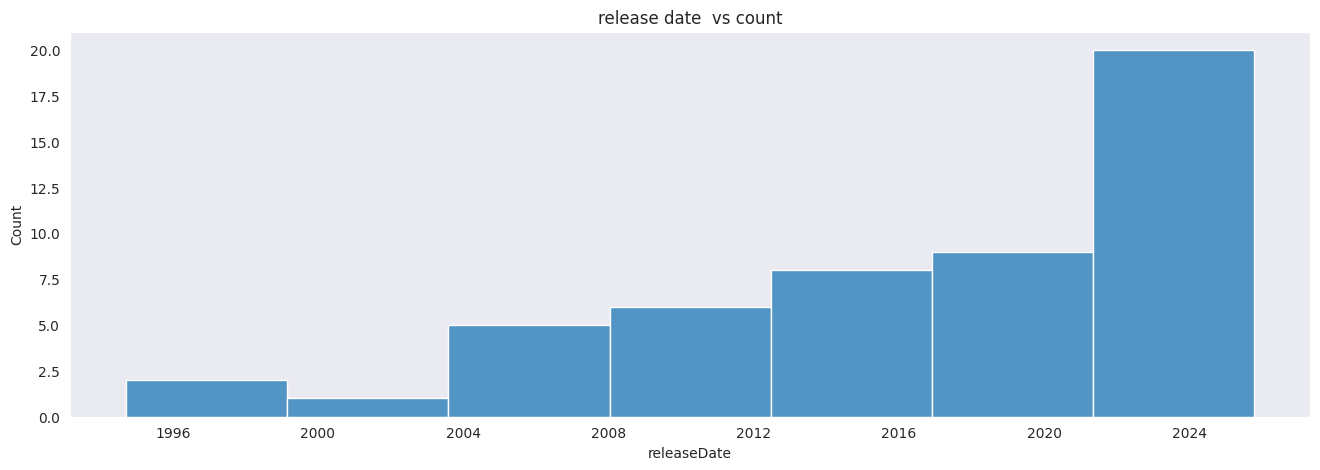

In [ ]:
# hist graph for release date vs count
sns.set_style("dark");
plt.figure(figsize=(16 , 5));

plt.title("release date  vs count")
sns.histplot( x = "releaseDate" , data = tv_show_df)

its distributed ascending . max in range of 2024 - 2025

Text(0.5, 1.0, 'release date  vs count')

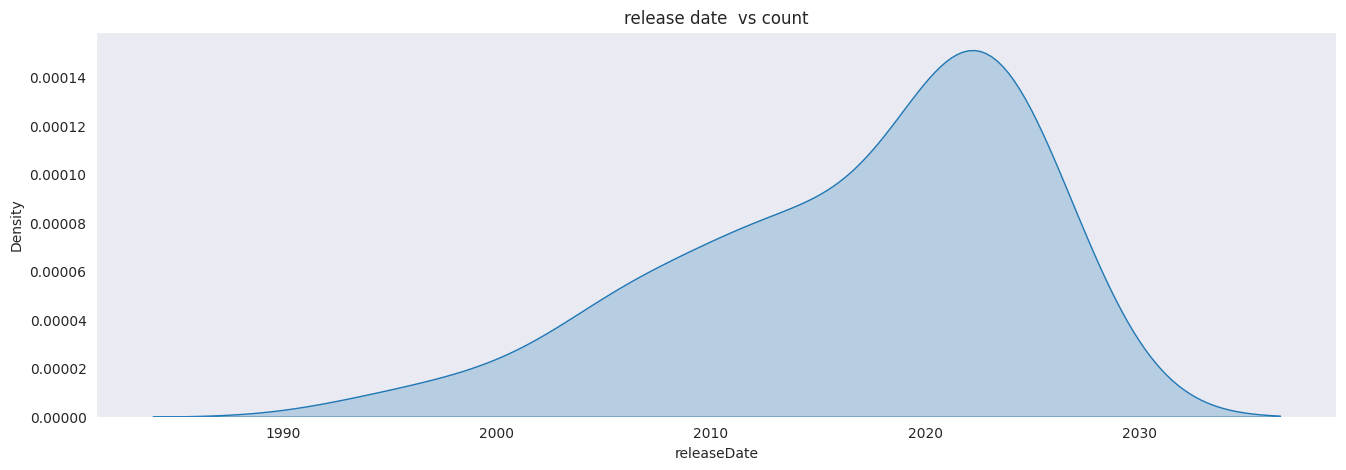

In [ ]:
#kde plot
plt.figure(figsize=(16 , 5));
sns.kdeplot(x = "releaseDate" , data = tv_show_df , fill = True)
plt.title("release date  vs count")

<Axes: title={'center': 'release box plot'}, xlabel='releaseDate'>

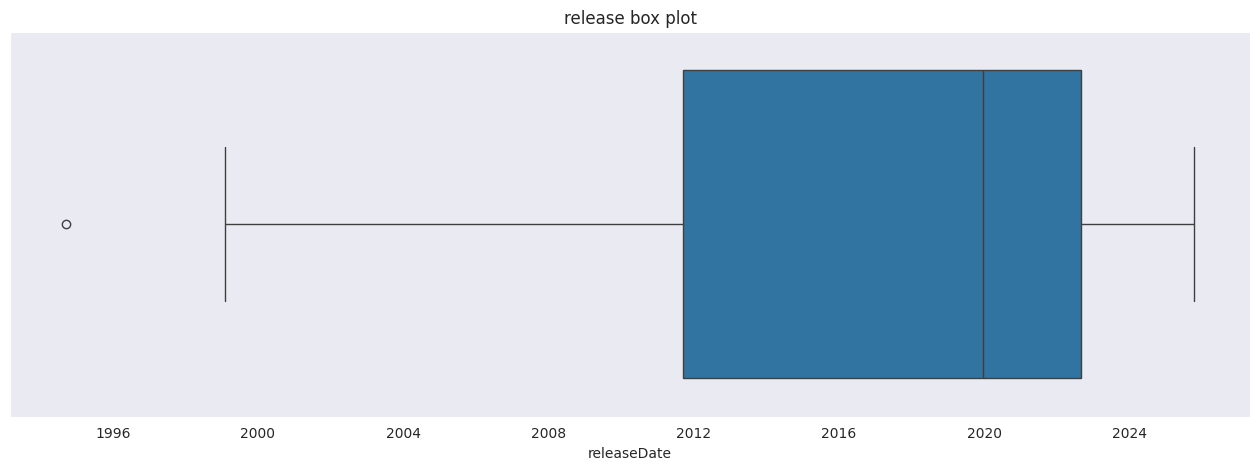

In [ ]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("release box plot")
sns.boxplot(x=tv_show_df["releaseDate"])

there are out liers which we will be imputing . its better to clip these data to the interquartile range (IQR)

### **Average run time**

<Axes: title={'center': 'Average run time vs count '}, xlabel='avgRunTime', ylabel='Count'>

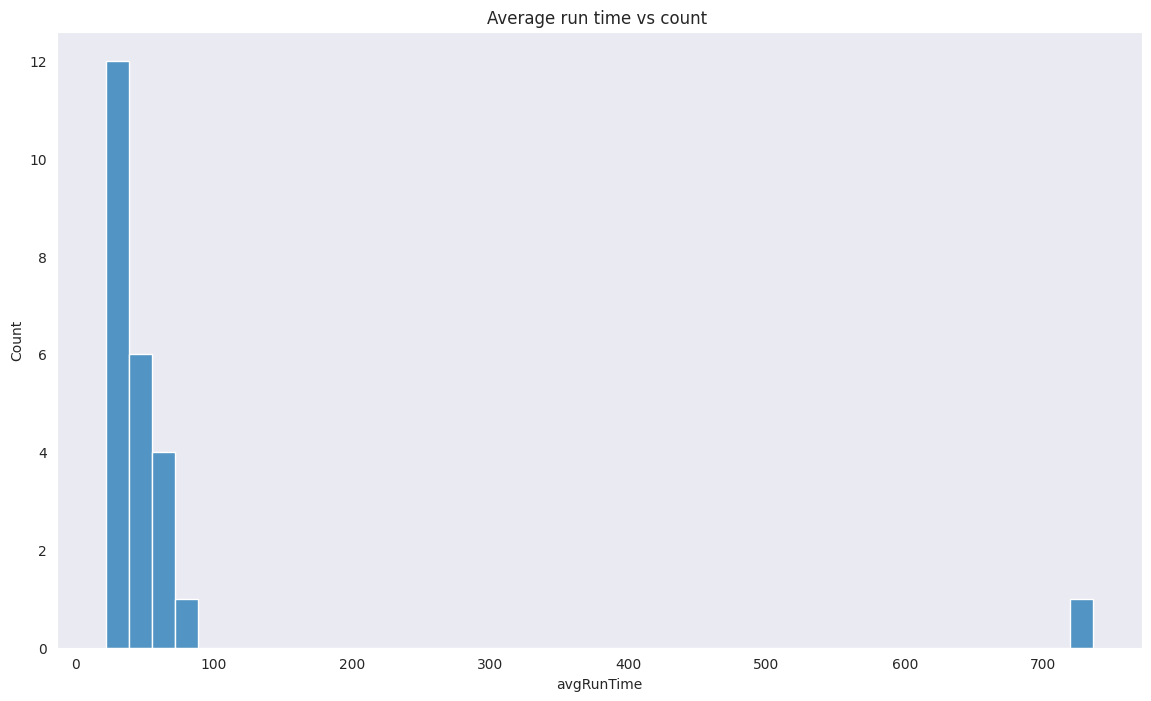

In [ ]:
# lets plot hist plot for average run time
plt.figure(figsize=(14, 8));
plt.title("Average run time vs count ")
sns.histplot(x ="avgRunTime" , data = tv_show_df)

maximum are below 100  , we can see one above 700 min as well .

<Axes: title={'center': 'Average run time vs count '}, xlabel='avgRunTime', ylabel='Density'>

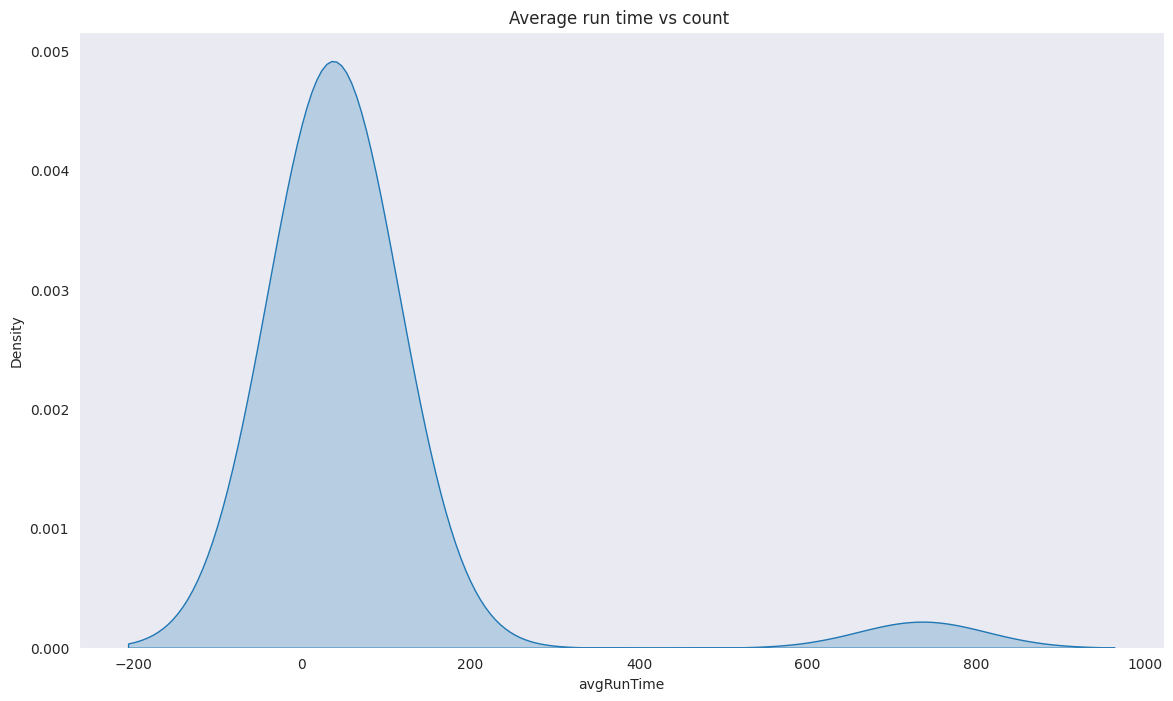

In [ ]:
plt.figure(figsize=(14, 8));
plt.title("Average run time vs count ")
# let's have a kde plot
sns.kdeplot(x = "avgRunTime", data = tv_show_df , fill = True)

<Axes: title={'center': 'run time box plot'}, xlabel='avgRunTime'>

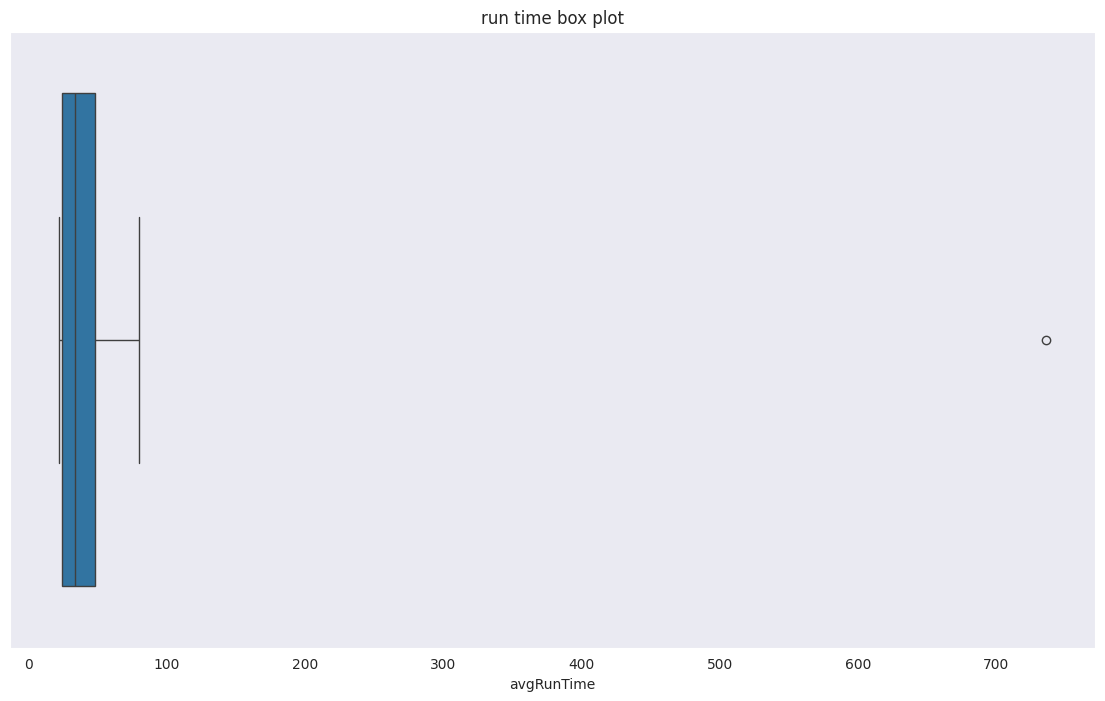

In [ ]:
# lets also draw a box plot
plt.figure(figsize=(14 , 8));
plt.title("run time box plot")
sns.boxplot(x= tv_show_df["avgRunTime"])

here as well we will clip them to iqr

### **Total Seasons**

<Axes: title={'center': 'total season vs count '}, xlabel='totalSeasons', ylabel='Count'>

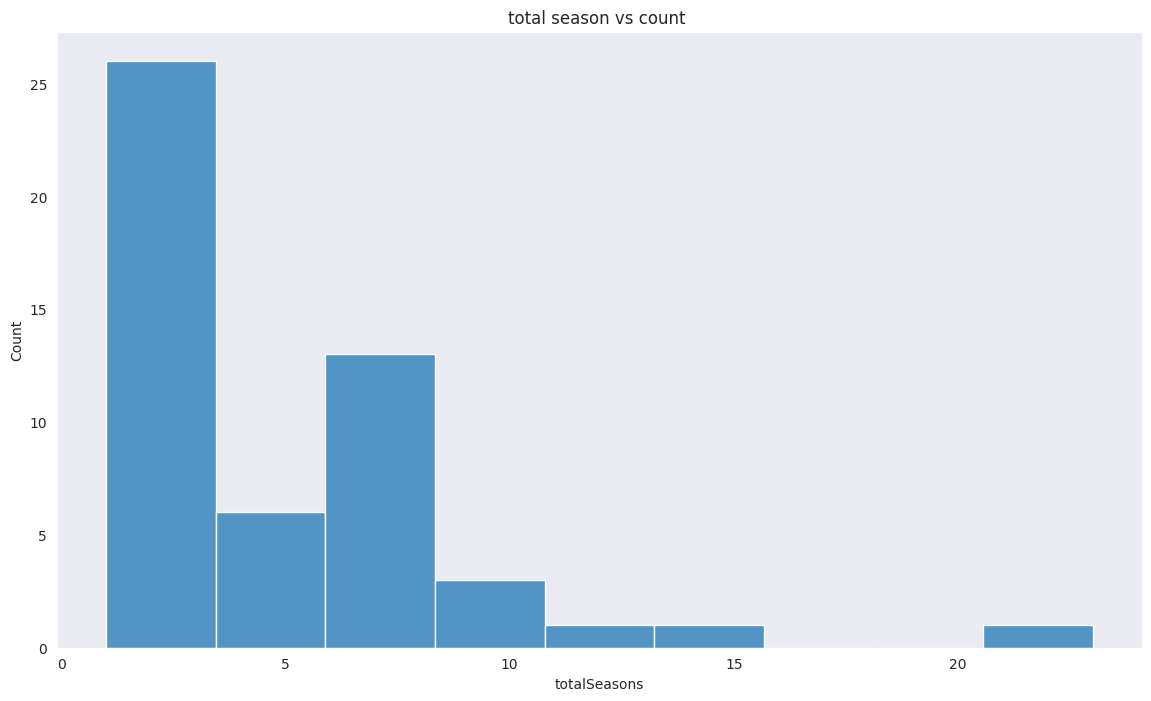

In [ ]:
# let's have a hist plot
plt.figure(figsize=(14, 8));
plt.title("total season vs count ")
sns.histplot(x ="totalSeasons" , data = tv_show_df)

magority have 1 season , rest are quite in the range of 1 - 10  

<Axes: title={'center': 'total season vs count '}, xlabel='totalSeasons', ylabel='Density'>

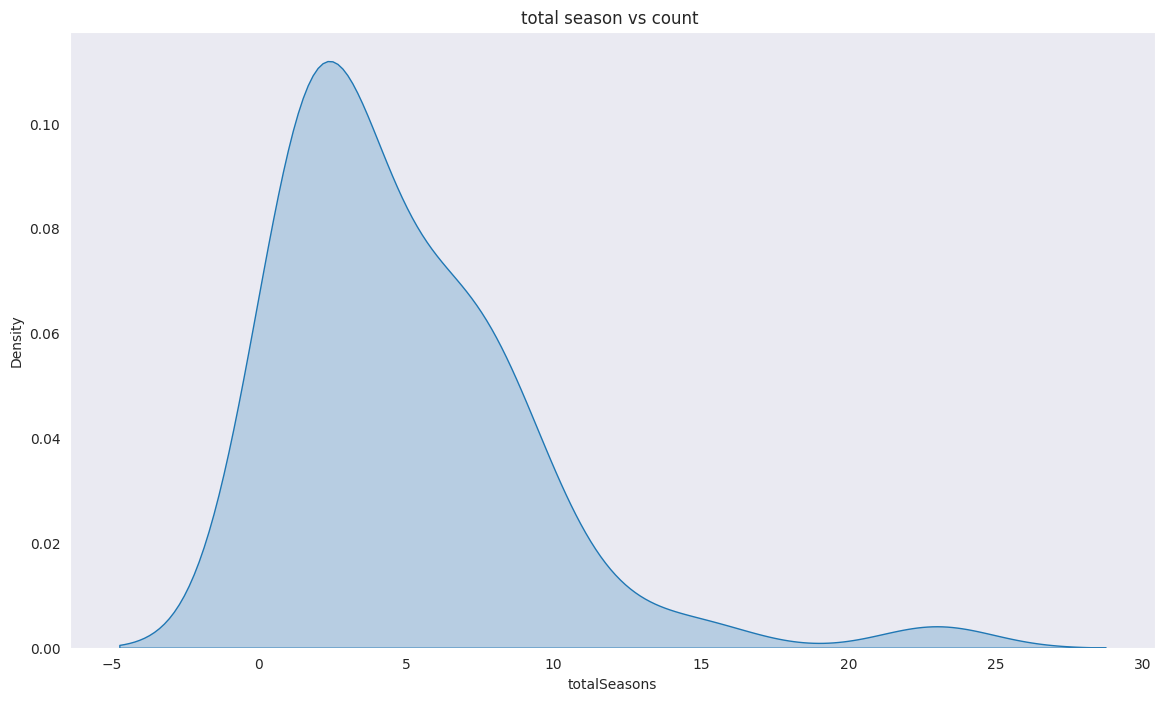

In [ ]:
# lets have a kde plot
plt.figure(figsize=(14, 8));
plt.title("total season vs count ")
sns.kdeplot(x ="totalSeasons" , data = tv_show_df , fill= True)

<Axes: title={'center': 'total season box plot'}, xlabel='totalSeasons'>

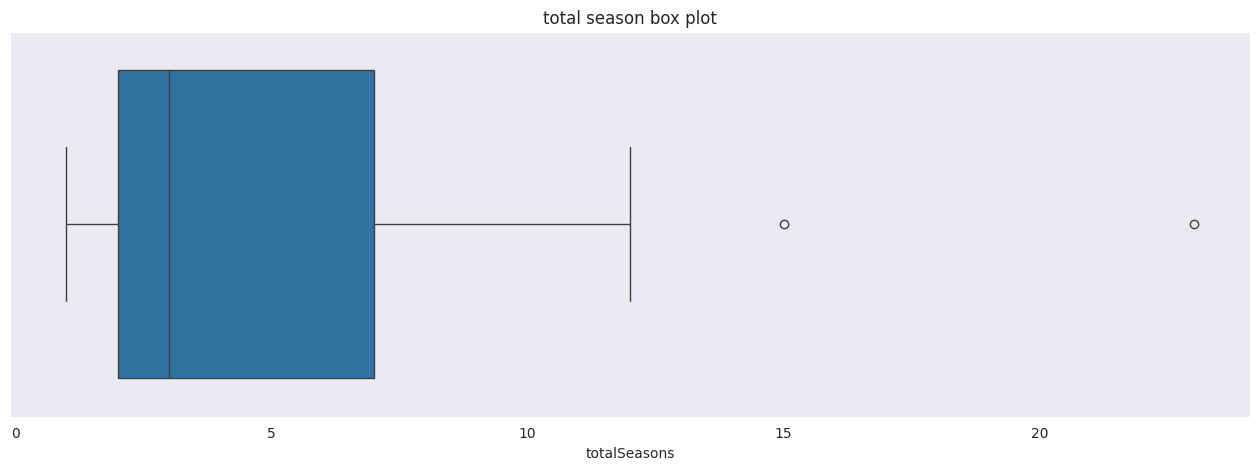

In [ ]:
# lets also draw a box plot
plt.figure(figsize=(16 , 5));
plt.title("total season box plot")
sns.boxplot(x=tv_show_df["totalSeasons"])

here as well we will clip values according to iqr

### Total Episodes

<Axes: title={'center': 'total episodes vs count '}, xlabel='totalEpisodes', ylabel='Count'>

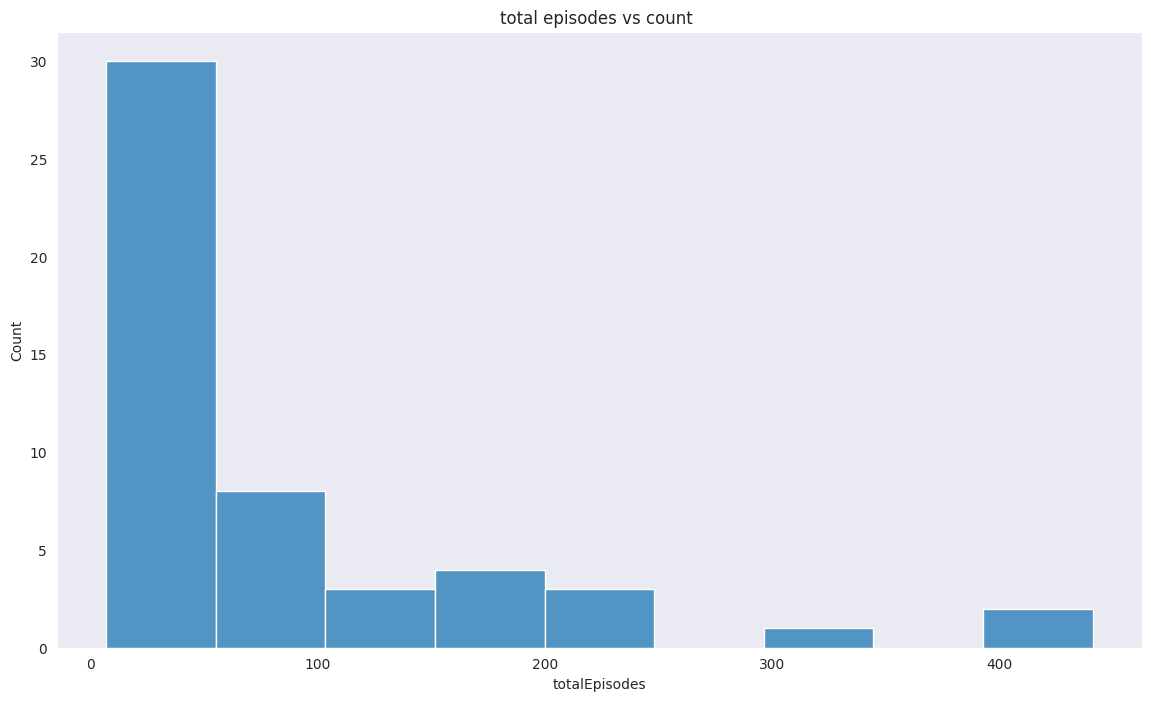

In [ ]:
# let's have a hist plot
plt.figure(figsize=(14, 8));
plt.title("total episodes vs count ")
sns.histplot(x ="totalEpisodes" , data = tv_show_df)

<Axes: title={'center': 'total season box plot'}, xlabel='totalEpisodes'>

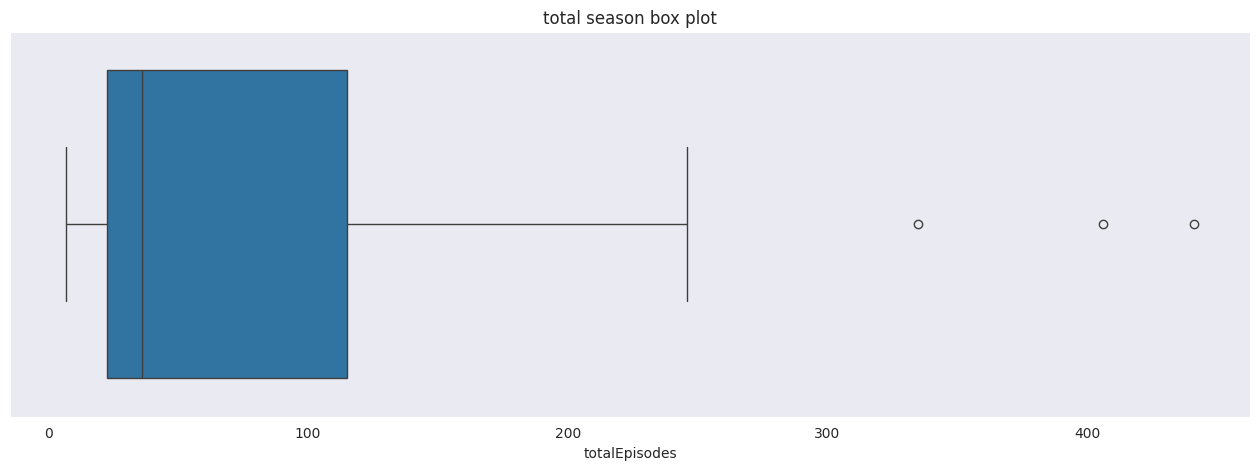

In [ ]:
plt.figure(figsize=(16 , 5));
plt.title("total season box plot")
sns.boxplot(x=tv_show_df["totalEpisodes"])

maxinumn in range of 50  to 100

## Categorical Feature Analysis

lets analyize our categorical data

In [ ]:
# lest all the categorical data
cat_columns = tv_show_df.select_dtypes(include="object")
cat_columns.columns

Index(['_id', 'title', 'description', 'genre', 'cast', 'directors',
       'languages', 'posterUrl', 'backdropUrl', 'status', 'tags',
       'youtubeVideoId', 'imdbId'],
      dtype='object')

In [ ]:
# create a copy of the data frame
tv_analysis = tv_show_df.copy()

### Genre

In [ ]:
# Replace the empty array or the missing values with unknown as place holder
tv_analysis["genre_filled"] = tv_analysis["genre"].apply(lambda x : x  if isinstance(x , list)  and len(x) > 0 else ["unknown"])

# explode and count including the placeholder
exploded_genre = tv_analysis["genre_filled"].explode()
genre_counts = exploded_genre.value_counts()

genre_counts


,count
genre_filled,
Drama,35
Fantasy,29
Action,27
Animation,17
Mystery,12
Crime,9
Comedy,9
Kids,1
War,1


In [ ]:
exploded_genre.unique()

array(['Mystery', 'Drama', 'Action', 'Fantasy', 'Animation', 'Crime',
       'Comedy', 'Kids', 'War', 'Family'], dtype=object)

we can see that only 10 of the geners are actually used .

In [ ]:
# lets conver this to df to draw plots
genre_df = genre_counts.reset_index()
genre_df.columns = ["genre" , "count"]

genre_df

,genre,count
0,Drama,35
1,Fantasy,29
2,Action,27
3,Animation,17
4,Mystery,12
5,Crime,9
6,Comedy,9
7,Kids,1
8,War,1
9,Family,1


<Axes: title={'center': 'Genere vs count '}, xlabel='Count', ylabel='Genre'>

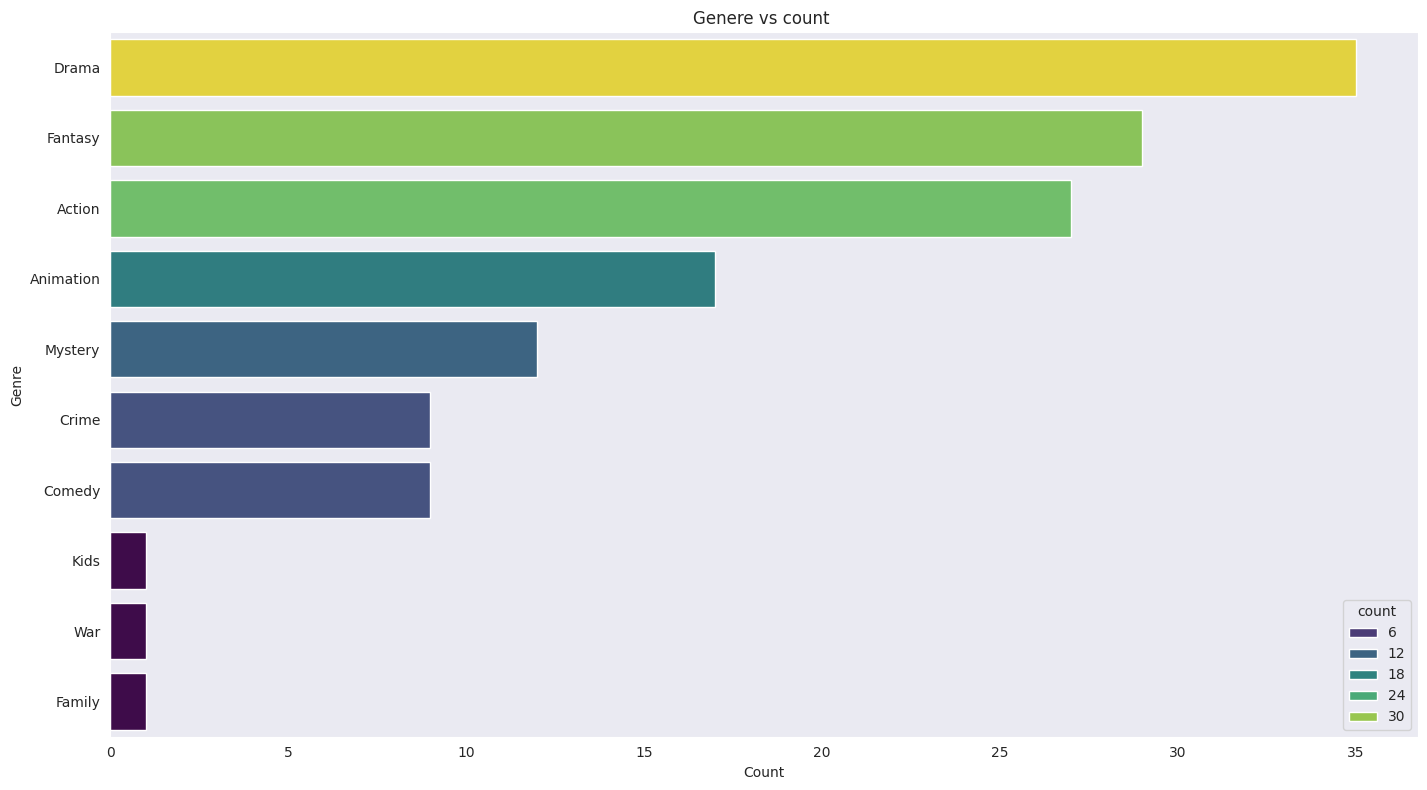

In [ ]:
# plot the distribution plot with respect to count
sns.set_style("dark")
plt.figure(figsize=(14, 8));
plt.title("Genere vs count ")
plt.xlabel("Count");
plt.ylabel('Genre')
plt.tight_layout()
sns.barplot(x='count', y='genre', data=genre_df, palette='viridis' , hue="count")


drama is has most count as of now .

### **Tags**

In [ ]:
# Replace the empty array or the missing values with unknown as place holder
tv_analysis["tags_filled"] = tv_analysis["tags"].apply(lambda x : x  if isinstance(x , list)  and len(x) > 0 else ["unknown"])

# explode and count including the placeholder
exploded_tags = tv_analysis["tags_filled"].explode()
tags_counts = exploded_tags.value_counts()

## convert to df
tags_df = tags_counts.reset_index()
tags_df.columns = ["tag" , 'count']
tags_df

,tag,count
0,3d animation,17
1,Dark comedy,14
2,Supernatural,9
3,unknown,9
4,Fantasy World,9
5,Adult,7
6,Friendship,6
7,Shounen,6
8,Dark,5
9,Super power,4


<Axes: title={'center': 'tags vs count '}, xlabel='Count', ylabel='Genre'>

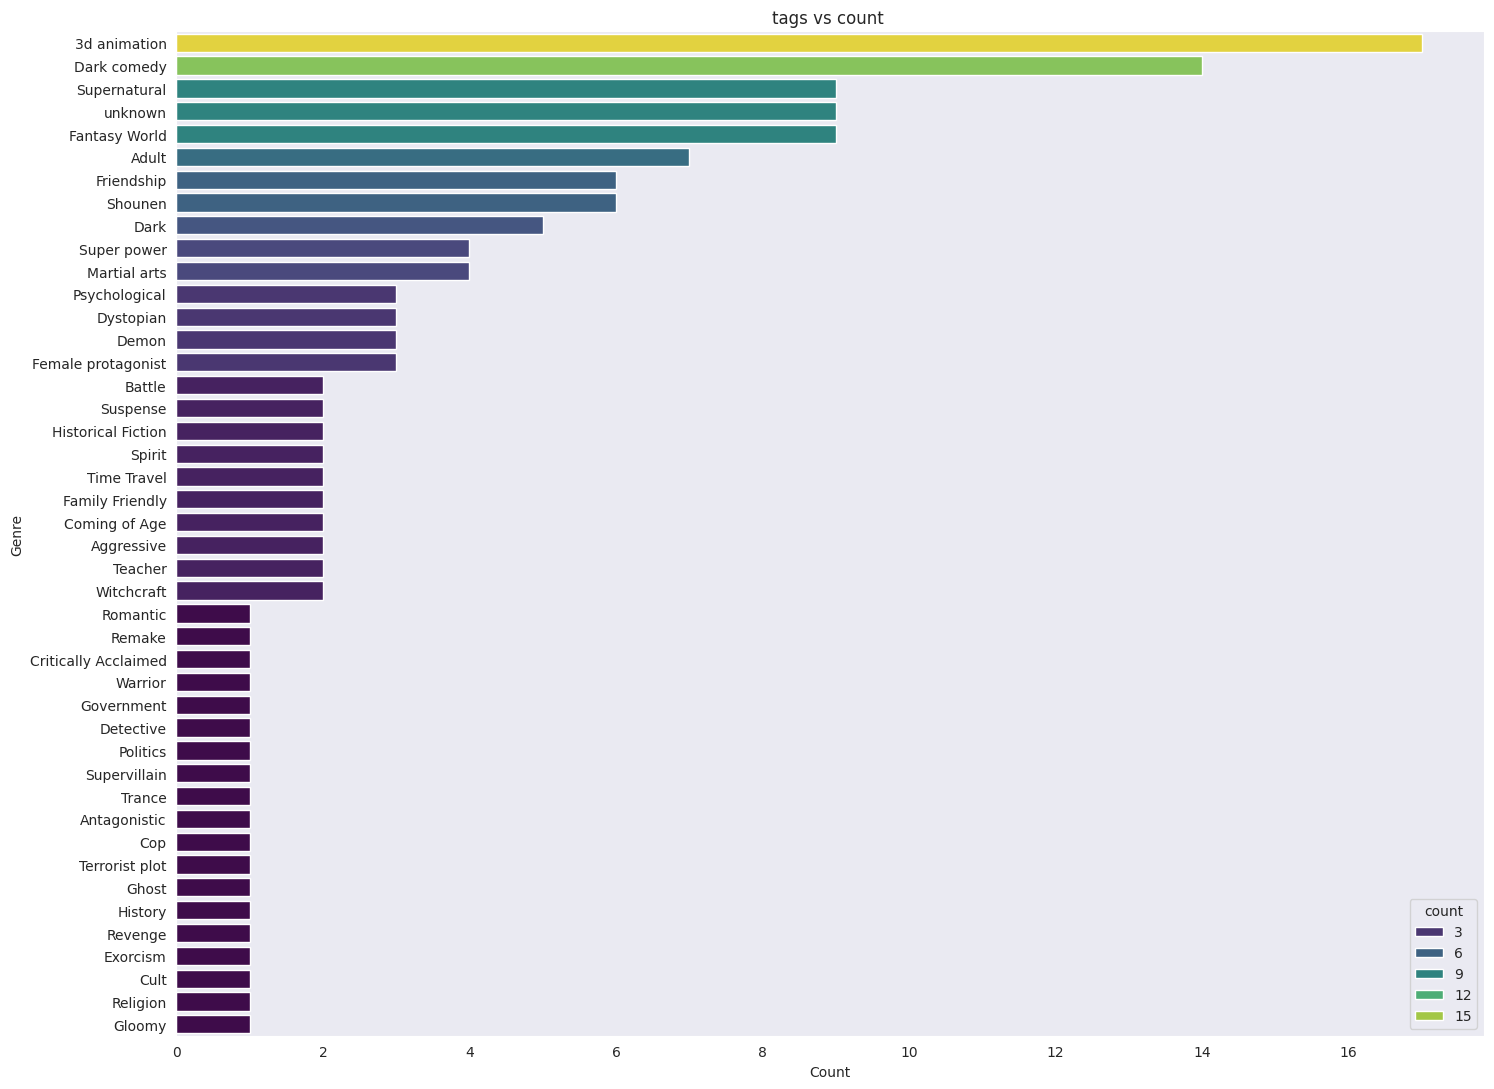

In [ ]:
# plot the tags distribution plot with respect to count
sns.set_style("dark")
plt.figure(figsize=(14, 11));
plt.title("tags vs count ")
plt.xlabel("Count");
plt.ylabel('Genre')
plt.tight_layout()
sns.barplot(x='count', y='tag', data=tags_df, palette='viridis' , hue="count")

3d animation and dark comidy are quite high . as we have used 43 unique tags .

### **isActive **

any non active to be removed from training anyway

<Axes: xlabel='isActive', ylabel='count'>

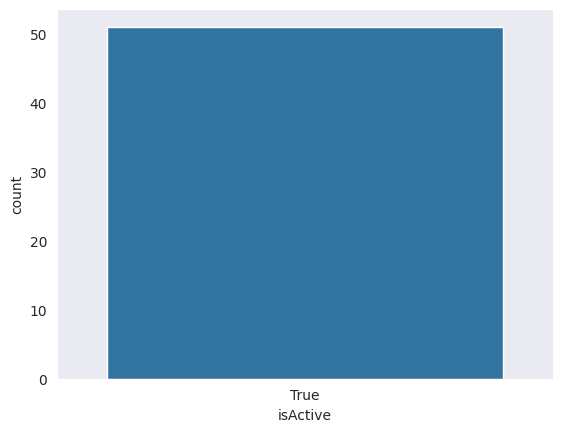

In [ ]:
# lest check active and non active
sns.countplot(x= "isActive" , data = tv_show_df )

currently everything is active

### Average rating & genre

In [ ]:
# explode genre
exploded_genre_rating =  tv_analysis.explode("genre")

# lets drop any missing values
exploded_genre_rating = exploded_genre_rating.dropna(subset= ["genre" , "averageRating"])

# group by genere : calculate the count and mean of average rating
genre_stats = exploded_genre_rating.groupby("genre").agg(
    Count = ("genre" ,"size"),
    AvgRating= ("averageRating" , "mean")
).reset_index()

genre_stats

,genre,Count,AvgRating
0,Action,27,8.166667
1,Animation,17,8.370588
2,Comedy,9,8.411111
3,Crime,9,8.033333
4,Drama,35,8.154286
5,Family,1,8.100000
6,Fantasy,29,8.351724
7,Kids,1,8.000000
8,Mystery,12,8.250000
9,War,1,8.100000


we can see that most have the average of 8 . not much useful imformation

<Axes: title={'center': 'genere vs count with averating'}, xlabel='Count', ylabel='genre'>

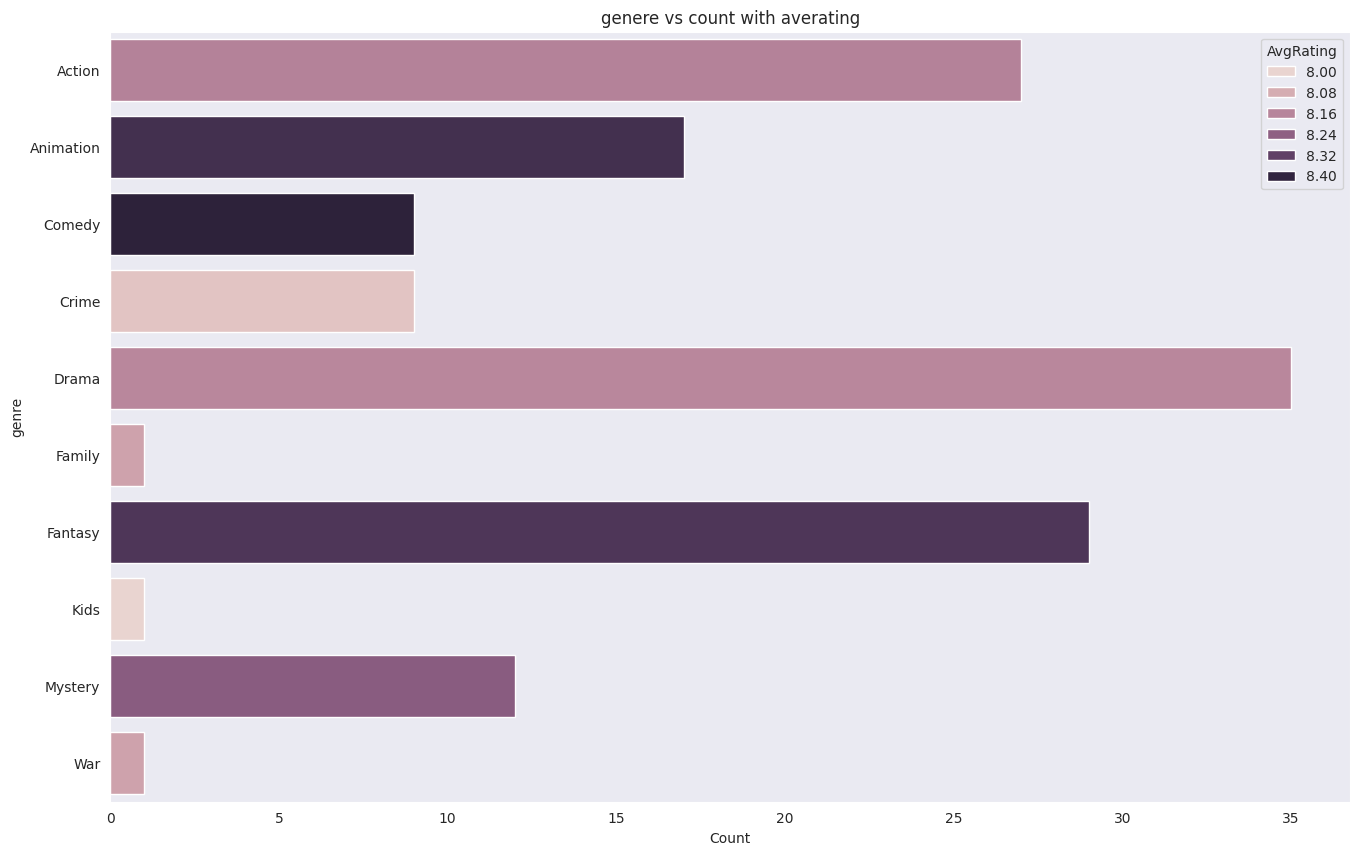

In [ ]:
# lets plot a graph
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("genere vs count with averating")
sns.barplot(x= "Count" , y= "genre" , data = genre_stats , hue= "AvgRating")

In [ ]:
# sort by count
genre_stats = genre_stats.sort_values("Count" , ascending=False)

<Axes: title={'center': 'genere vs count with averating'}, xlabel='Count', ylabel='genre'>

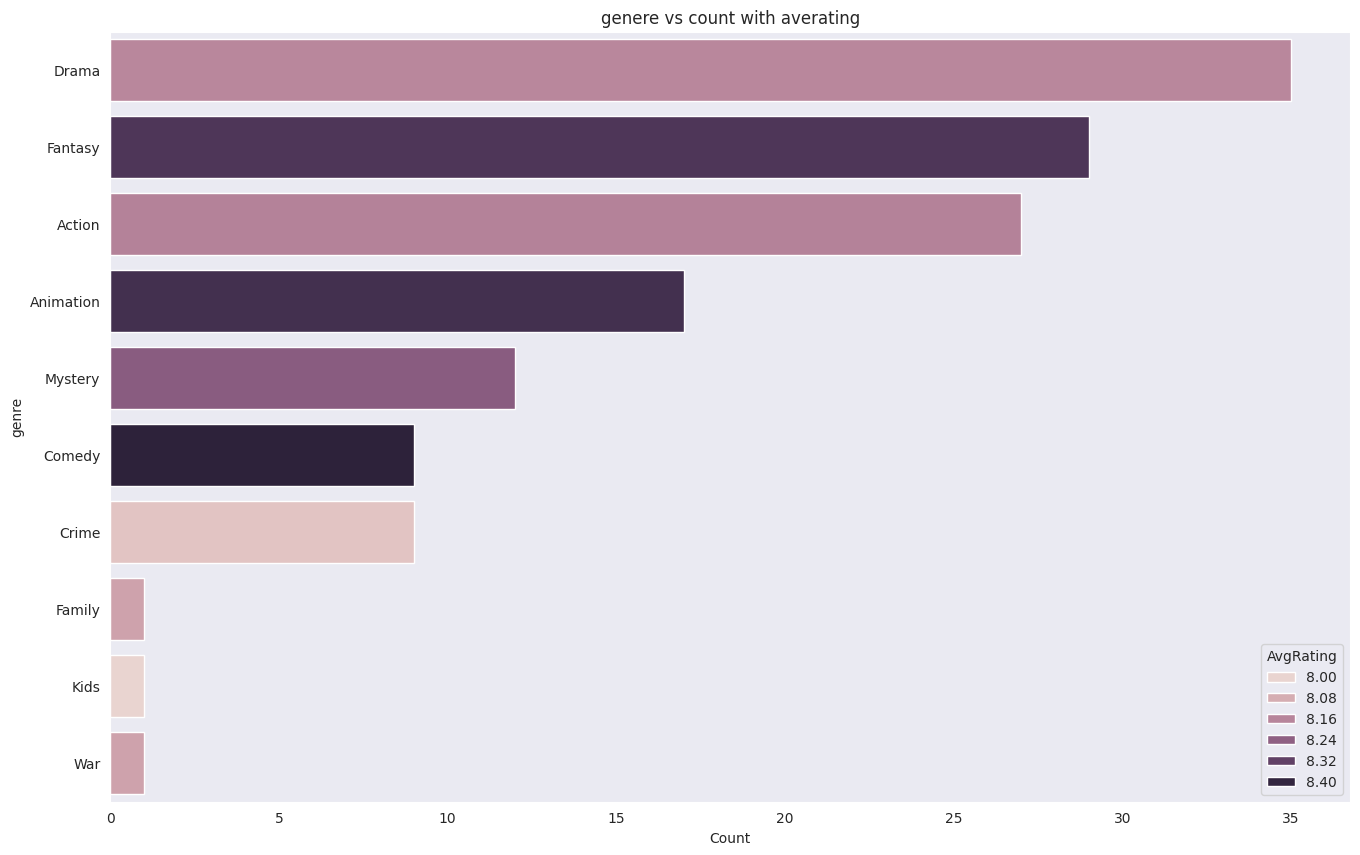

In [ ]:
plt.figure(figsize=(16, 10));

plt.title("genere vs count with averating")
sns.barplot(x= "Count" , y= "genre" , data = genre_stats , hue= "AvgRating")

/tmp/ipython-input-3507860723.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data = genre_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )


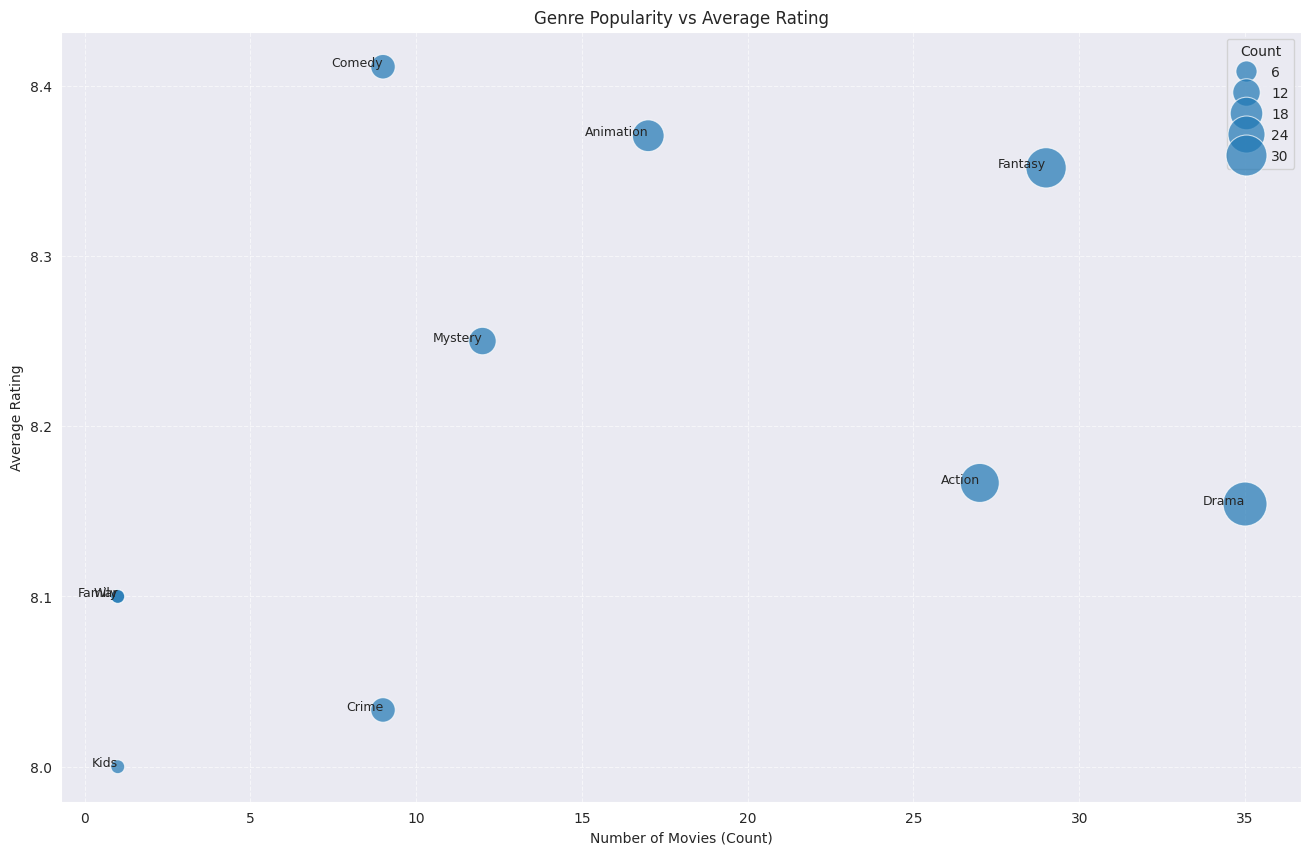

In [ ]:
# lest also have a scatter plot  with respect to count and avergae rating on y
plt.figure(figsize=(16, 10));
sns.scatterplot(data = genre_stats , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )
# Label points with genre names for better readability
for i, row in genre_stats.iterrows():
    plt.text(row['Count'], row['AvgRating'], row['genre'], fontsize=9, ha='right')

plt.title('Genre Popularity vs Average Rating')
plt.xlabel('Number of Movies (Count)')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)

/tmp/ipython-input-4043459094.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


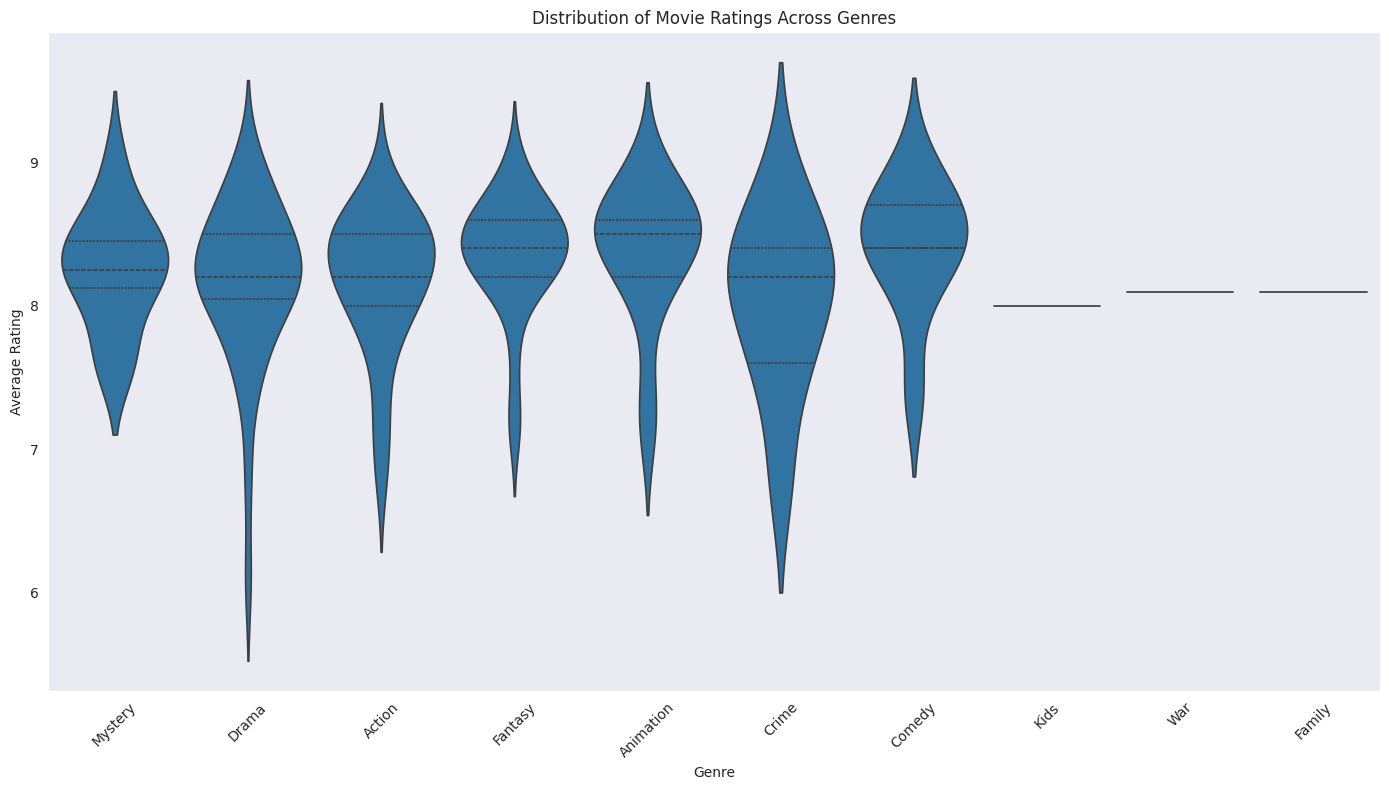

In [ ]:
# violin plot

plt.figure(figsize=(14, 8));
sns.violinplot(
    x= "genre",
    y = "averageRating",
    data = exploded_genre_rating,
    inner= "quartile",
    scale= "width"
)

plt.xticks(rotation=45)
plt.title('Distribution of Movie Ratings Across Genres')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

### Average rating & tags

In [ ]:
# explode tags
exploded_tag_rating =  tv_analysis.explode("tags")

# lets drop any missing values
exploded_tags_rating = exploded_tag_rating.dropna(subset= ["tags" , "averageRating"])

# group by tags : calculate the count and mean of average rating
tags_stats = exploded_tags_rating.groupby("tags").agg(
    Count = ("tags" ,"size"),
    AvgRating= ("averageRating" , "mean")
).reset_index()

tags_stats

,tags,Count,AvgRating
0,3d animation,17,8.370588
1,Adult,7,8.314286
2,Aggressive,2,8.150000
3,Antagonistic,1,8.100000
4,Battle,2,7.700000
5,Coming of Age,2,8.350000
6,Cop,1,8.400000
7,Critically Acclaimed,1,8.600000
8,Cult,1,8.600000
9,Dark,5,8.380000


not much relation hear as well.

In [ ]:
# lets sort by count
tags_stats_sorted =tags_stats.sort_values("Count" , ascending=False)

<Axes: title={'center': 'tags vs count with averating'}, xlabel='Count', ylabel='tags'>

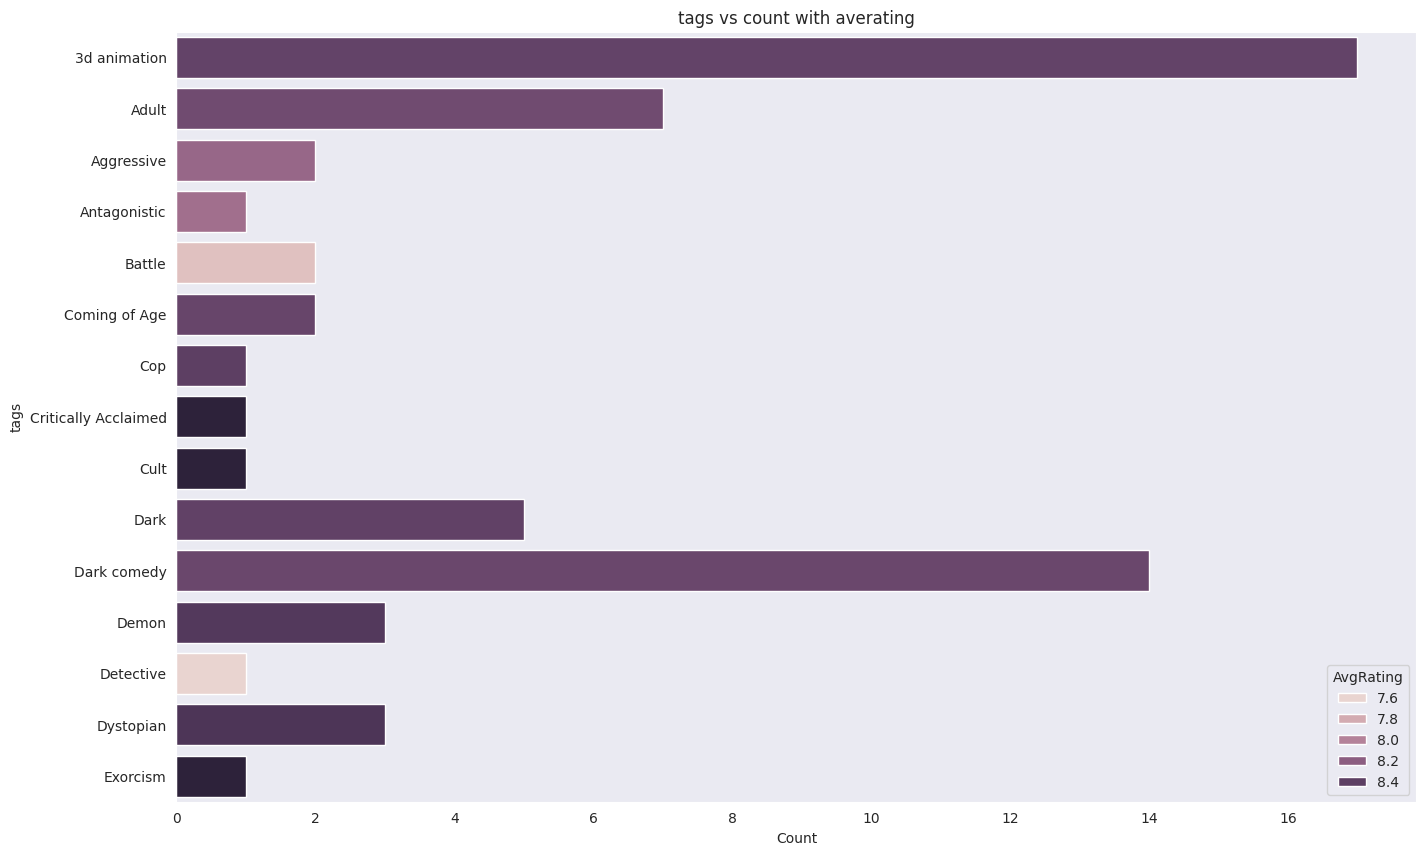

In [ ]:
# lets plot the bar graph lets only take top 15
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("tags vs count with averating")
sns.barplot(x= "Count" , y= "tags" , data = tags_stats.head(15) , hue= "AvgRating")

<Axes: title={'center': 'tags vs count with averating'}, xlabel='Count', ylabel='tags'>

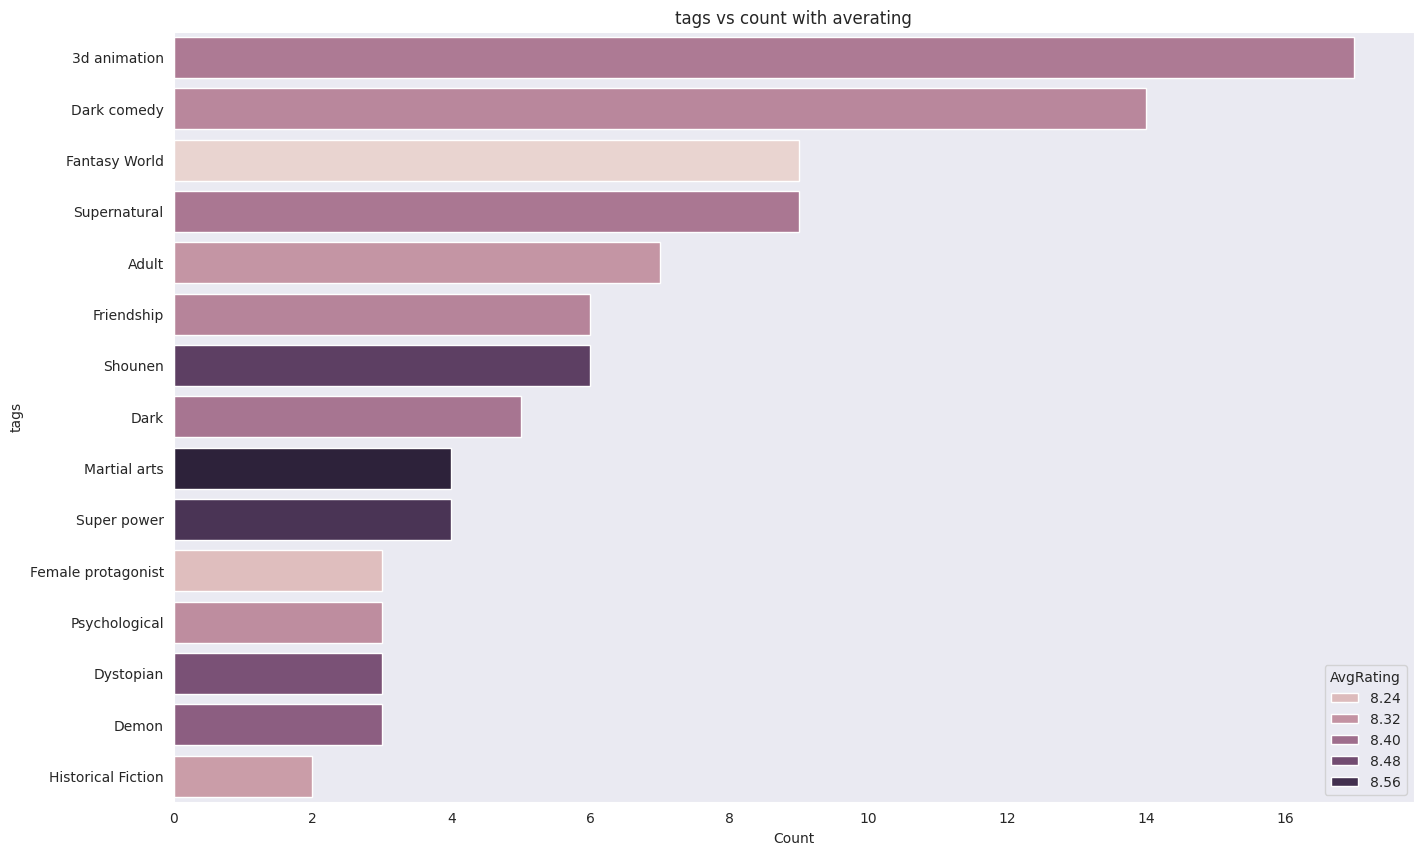

In [ ]:
# lets plot the bar graph lets only take top 15 and sorted by count
sns.set_style("dark")
plt.figure(figsize=(16, 10));

plt.title("tags vs count with averating")
sns.barplot(x= "Count" , y= "tags" , data = tags_stats_sorted.head(15) , hue= "AvgRating")

/tmp/ipython-input-2366181815.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data = tags_stats.head(20) , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )


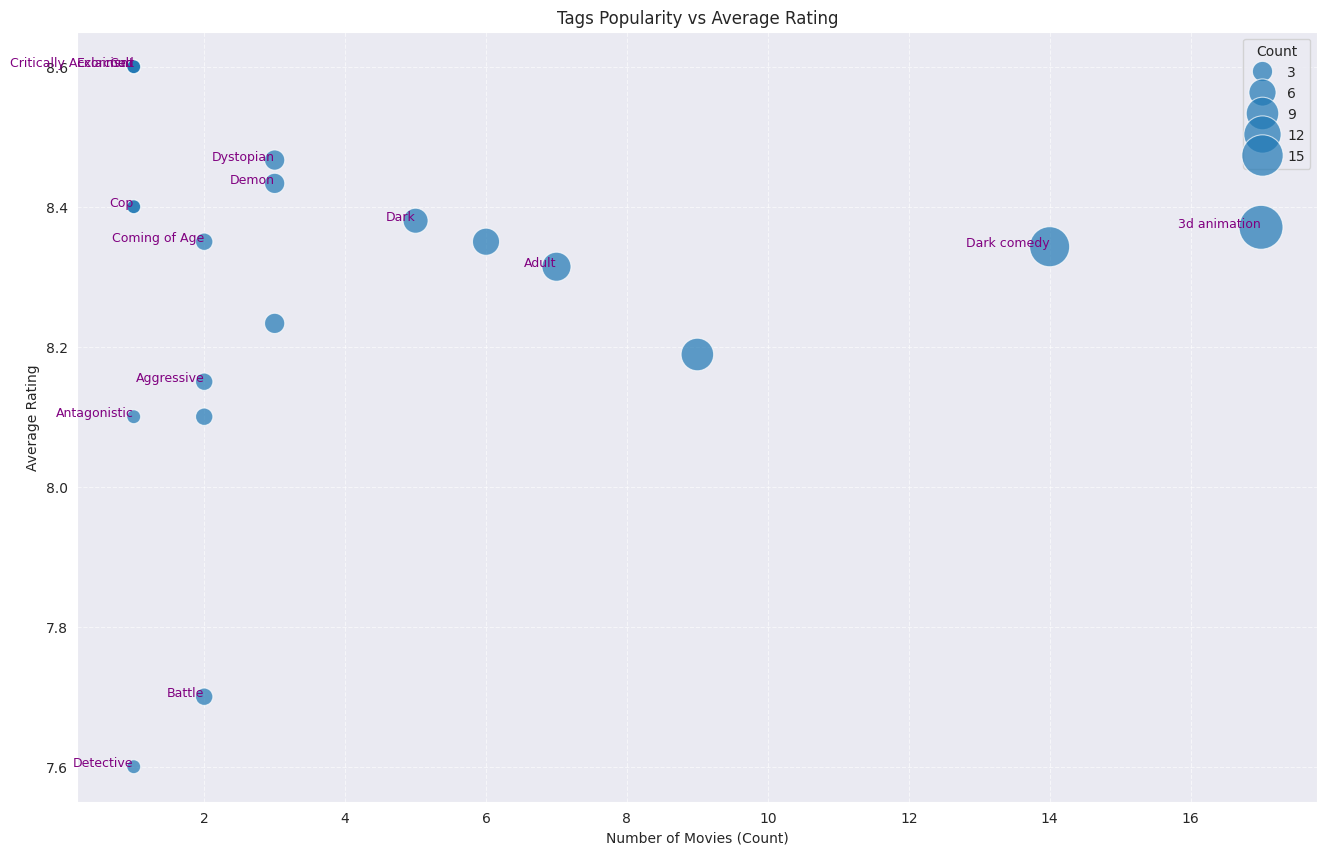

In [ ]:
# let get a scatter plot for better visulization lets only take top 20
plt.figure(figsize=(16, 10));
sns.scatterplot(data = tags_stats.head(20) , x = "Count" ,y = "AvgRating"  , size = "Count" , sizes=(100, 1000) , alpha= 0.7 , palette='viridis' )

# Label points with tags names for better readability
for i, row in tags_stats.head(15).iterrows():
    plt.text(row['Count'], row['AvgRating'], row['tags'], fontsize=9, ha='right' , color="purple")

plt.title('Tags Popularity vs Average Rating')
plt.xlabel('Number of Movies (Count)')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)

/tmp/ipython-input-1082579062.py:3: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


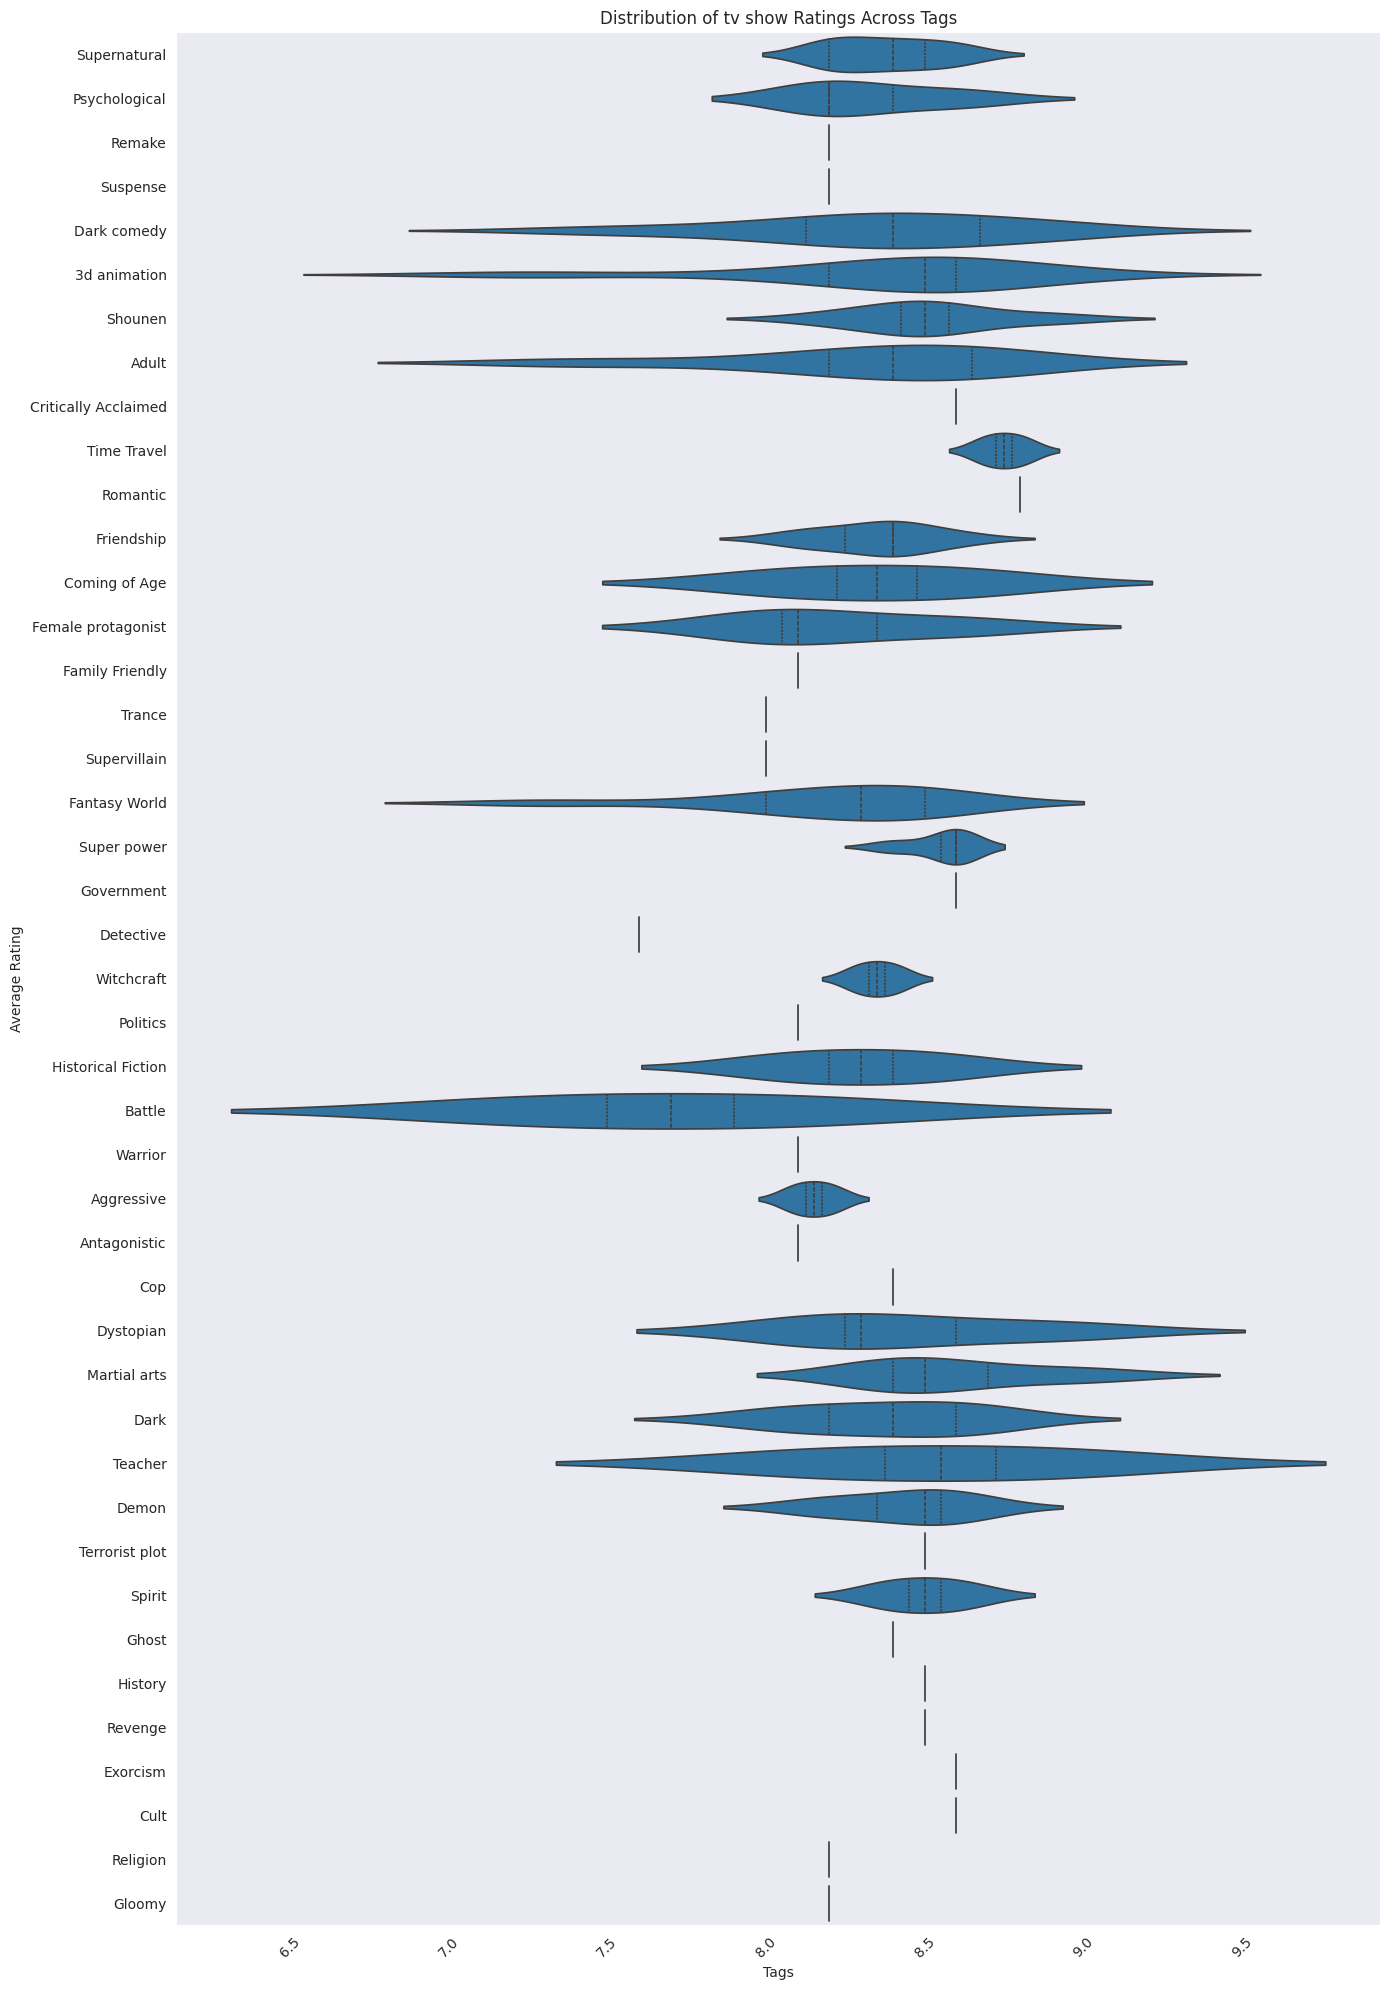

In [ ]:
# let also go for a voiline plot for distribution visualization
plt.figure(figsize=(14, 20));
sns.violinplot(
    x= "averageRating",
    y="tags",
    data = exploded_tags_rating,
    inner= "quartile",
    scale="width"
)

plt.xticks(rotation=45)
plt.title('Distribution of tv show Ratings Across Tags')
plt.xlabel('Tags')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3616611679.py:14: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


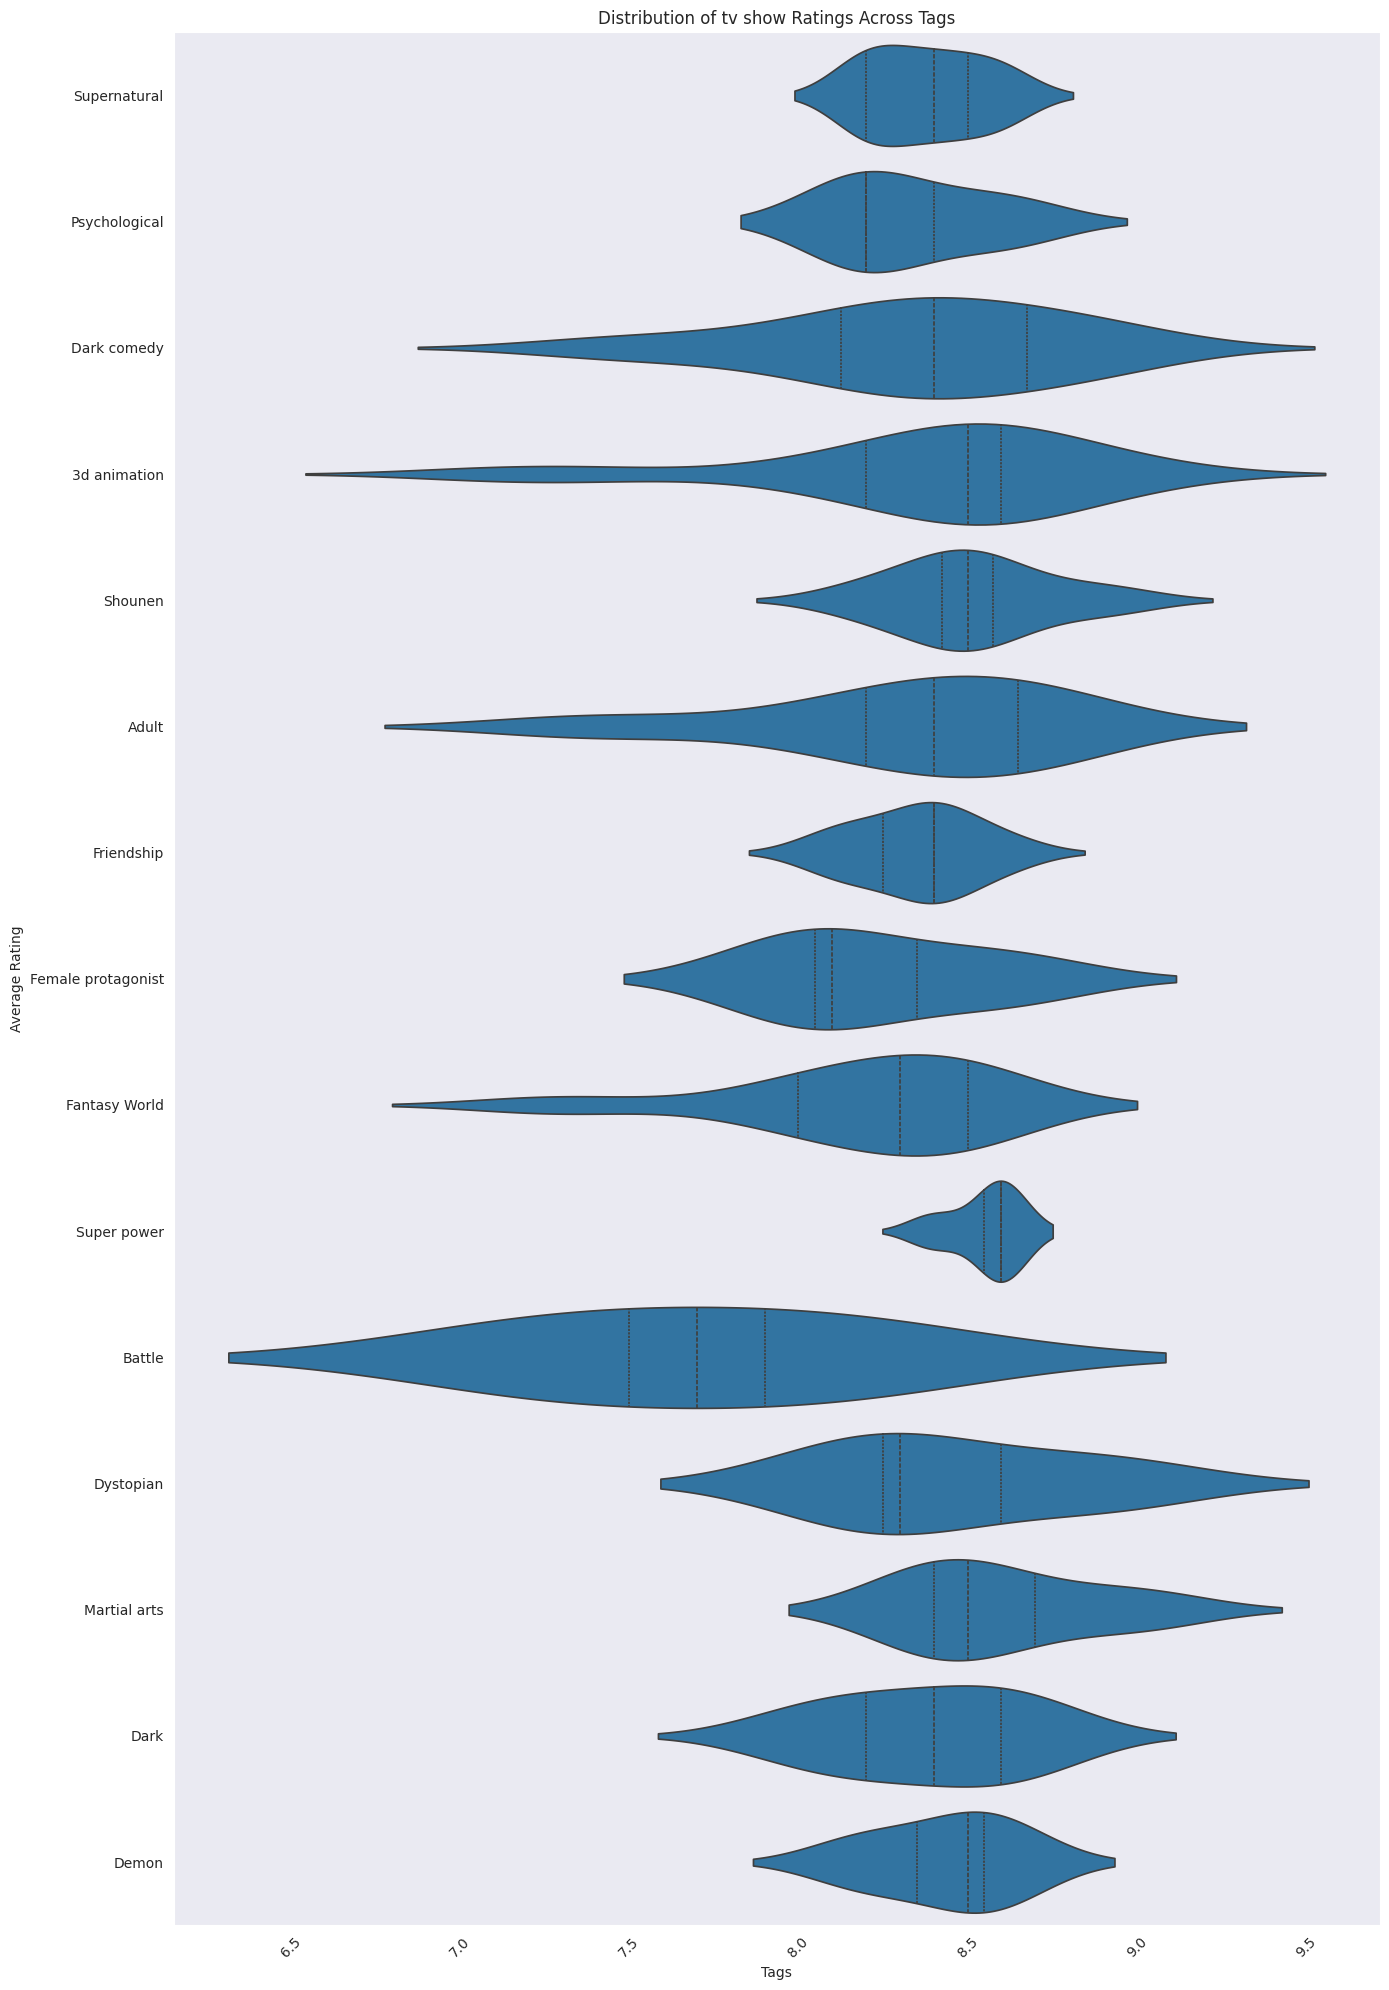

In [ ]:
# let also go for a voiline plot for distribution visualization TOP 15
top_n = 15
# Get top N tags by count
top_tags = (
    exploded_tags_rating['tags']
    .value_counts()
    .index[:top_n]
    .tolist()
)

filtered_df = exploded_tags_rating[exploded_tags_rating['tags'].isin(top_tags)]

plt.figure(figsize=(14, 20));
sns.violinplot(
    x= "averageRating",
    y="tags",
    data = filtered_df,
    inner= "quartile",
    scale="width"
)

plt.xticks(rotation=45)
plt.title('Distribution of tv show Ratings Across Tags')
plt.xlabel('Tags')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

### Status

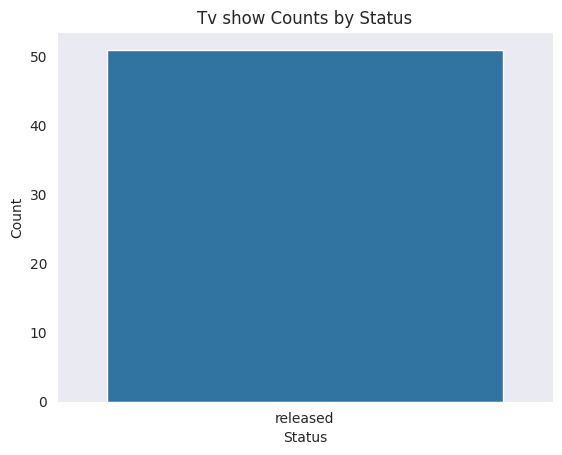

In [ ]:
# lest plot count of released and upcomming.
status_counts = tv_show_df['status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

sns.barplot(x='Status', y='Count', data=status_counts)
plt.title('Tv show Counts by Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

we only have released by now .

In [ ]:
# we will sking status with respect to count , genere

## Relationships & Correlations

/tmp/ipython-input-3502365409.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["averageRating"].replace(0, np.nan, inplace=True)
/tmp/ipython-input-3502365409.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

<Axes: title={'center': 'Scatter Plot of Average Rating vs Age Rating'}, xlabel='Age Rating', ylabel='Average Rating'>

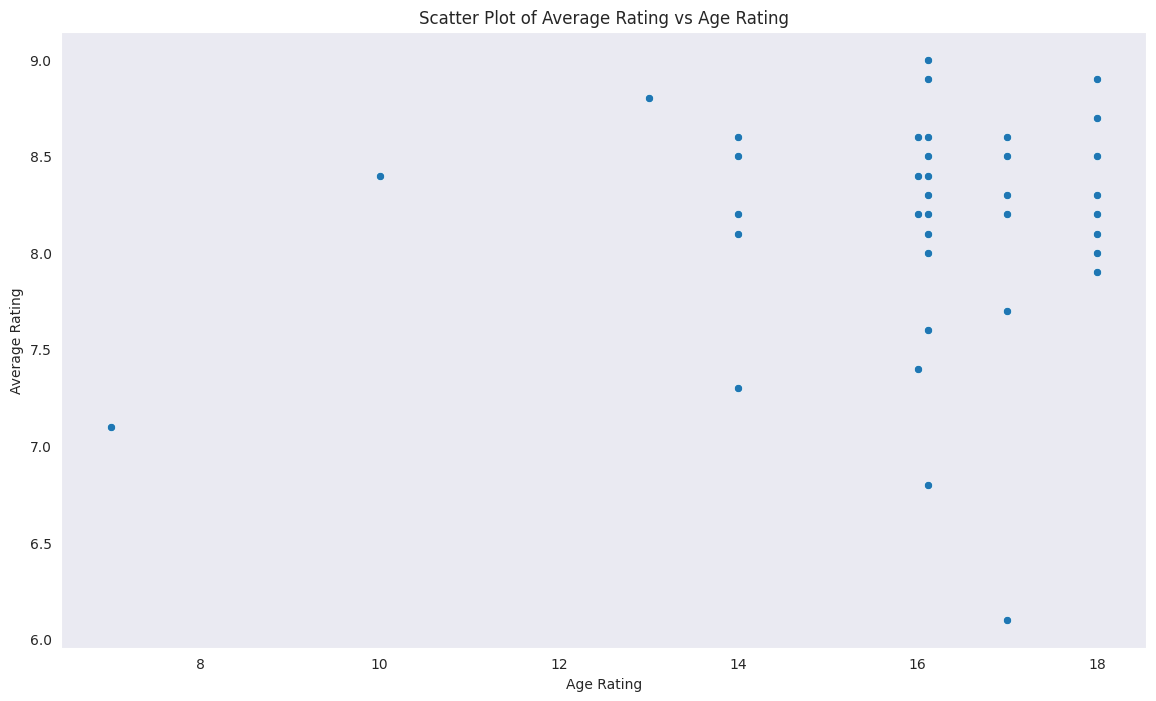

In [ ]:
from sklearn.impute  import SimpleImputer
# age rating vs average rating corelation with scatter plot
plt.figure(figsize=(14, 8));

# lets have a temp df with nulls handled\
df = tv_show_df.copy()

# define imputers
impute_mean = SimpleImputer(strategy="mean")

# Replace zeros with np.nan for imputation
df["averageRating"].replace(0, np.nan, inplace=True)
df["ageRating"].replace(0, np.nan, inplace=True)

df["averageRating"] = impute_mean.fit_transform(df[["averageRating"]])
df["ageRating"] = impute_mean.fit_transform(df[["ageRating"]])

# now lets create the plot
plt.xlabel("Age Rating")
plt.ylabel("Average Rating")
plt.title("Scatter Plot of Average Rating vs Age Rating")
sns.scatterplot(x="ageRating" ,y = "averageRating" , data = df)


there is no relationship observed

In [ ]:
# lets draw a pair plot of all numeric values , first lets drop non required columns
num_columns.drop(columns= ["tmdbId" , "__v" ] , inplace=True)
num_columns.columns

Index(['averageRating', 'totalSeasons', 'totalEpisodes', 'ageRating',
       'avgRunTime'],
      dtype='object')

In [ ]:
# lets impute avgRunTime with mean

df["avgRunTime"] = impute_mean.fit_transform(df[["avgRunTime"]])

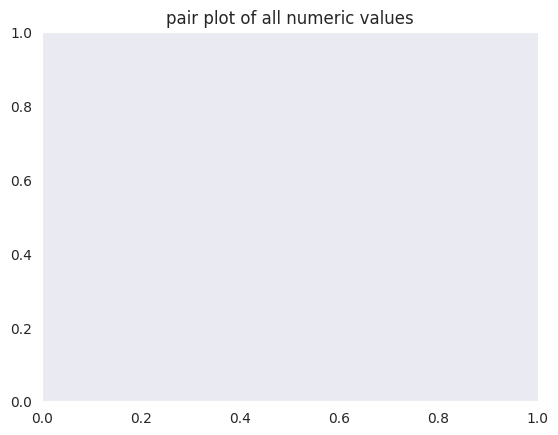

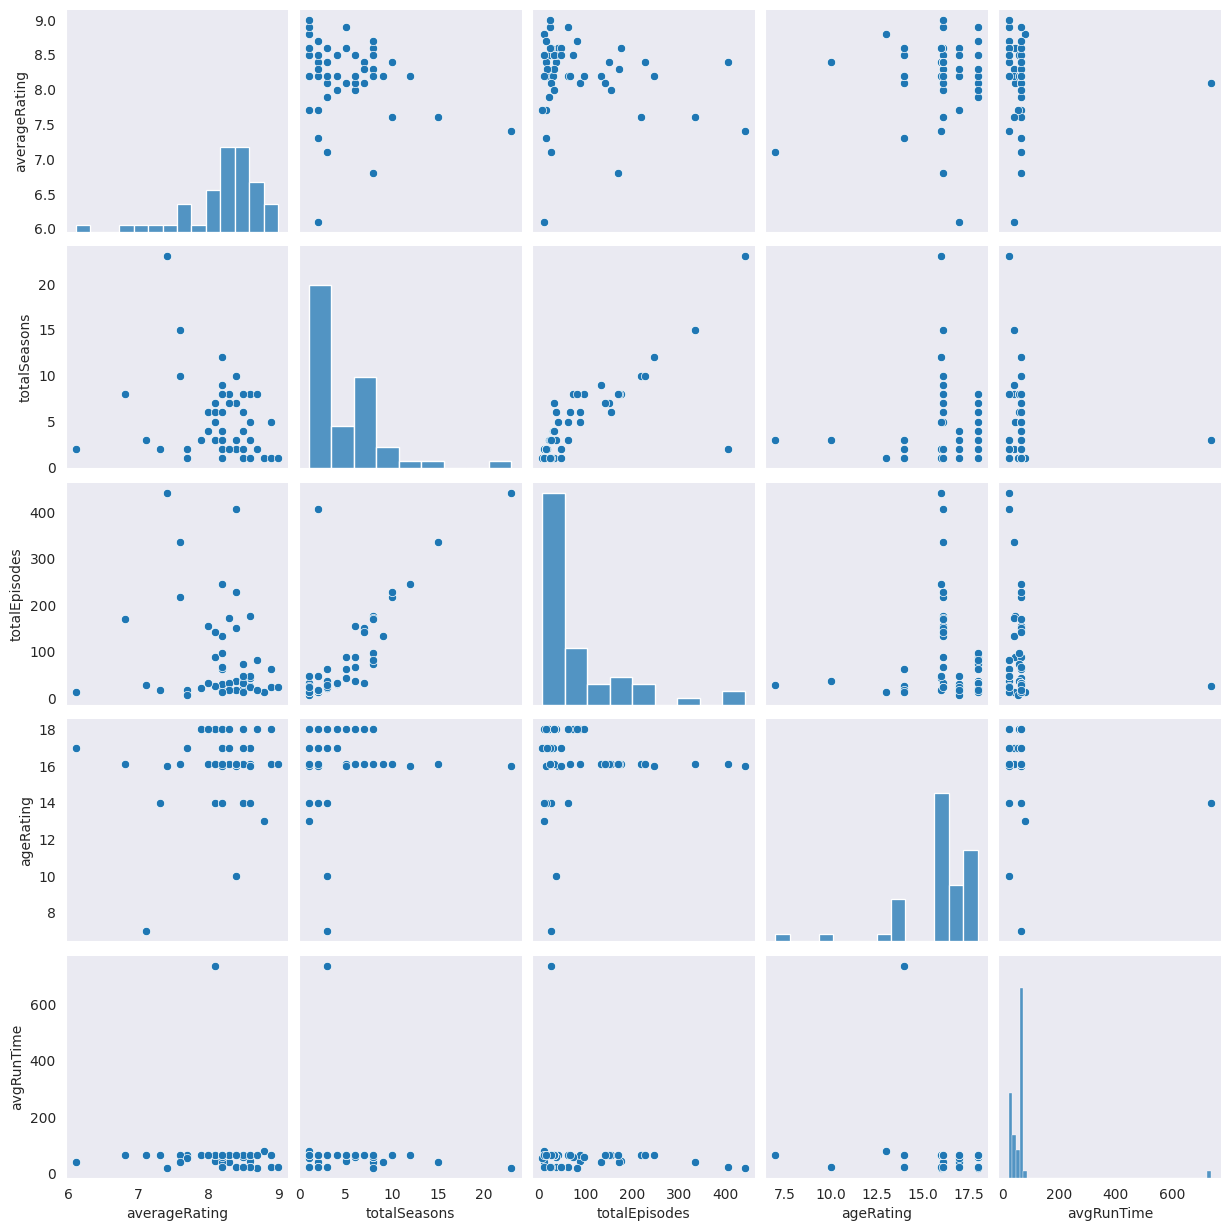

In [ ]:

# lets now plot the pair plot
plt.title("pair plot of all numeric values")
sns.pairplot( df[num_columns.columns])

total season and total episodes only have relation which is expected

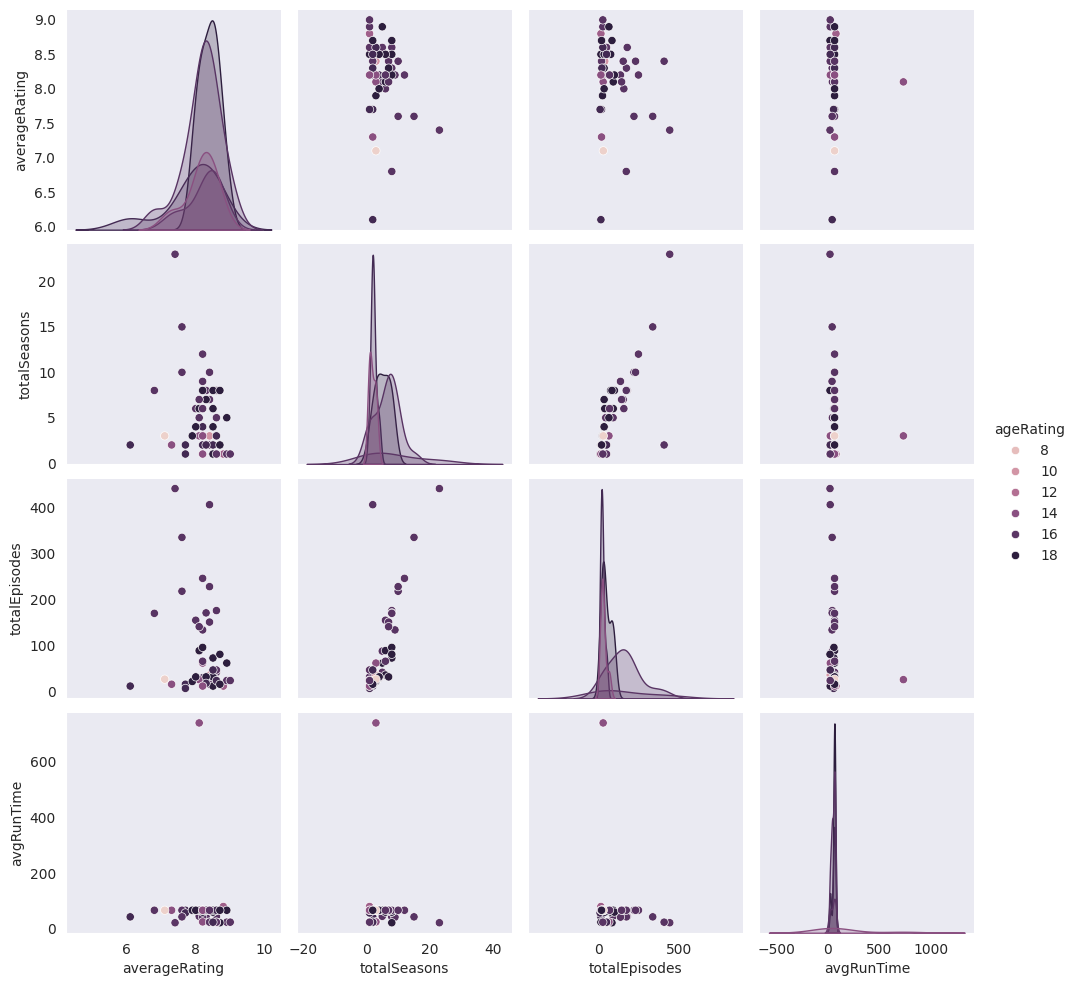

In [ ]:
# with age as hue
sns.pairplot( df[num_columns.columns] , hue= "ageRating")

Text(0.5, 1.0, 'Correlation Heatmap numeric data')

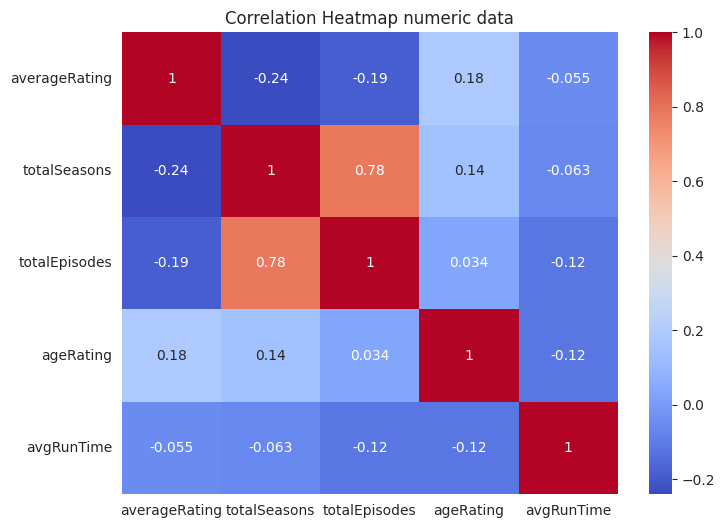

In [ ]:
# lets plot a corr realtion heat map

corr_matrix = df[num_columns.columns].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap numeric data")

# Data cleaning
now lets clear all the unwanted data from the data frame as per our observation and also impute missing values .

In [69]:
tv_show_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   _id             51 non-null     object             
 1   title           51 non-null     object             
 2   description     51 non-null     object             
 3   averageRating   51 non-null     float64            
 4   genre           51 non-null     object             
 5   releaseDate     51 non-null     datetime64[ns, UTC]
 6   cast            51 non-null     object             
 7   directors       51 non-null     object             
 8   languages       51 non-null     object             
 9   posterUrl       51 non-null     object             
 10  backdropUrl     51 non-null     object             
 11  isActive        51 non-null     bool               
 12  status          51 non-null     object             
 13  tags            51 non-null     objec

In [70]:
# lets create a copy of the data
df_clean = tv_show_df.copy()

#lets remove any inactive tv show before procceding further
df_clean = df_clean[df_clean["isActive"] == True]

# lest first define all the columns to drop
columns_to_drop = [
    '__v',           # MongoDB version key mot importent
    'updatedAt',     # Not needed for training
    'backdropUrl',   # URL - not useful for training
    'posterUrl',     # URL - not useful for training
    'isActive',      # We only want active data
    'youtubeVideoId',# Video ID - not useful for training
    "createdAt",     # not important data can be misleading
    'tmdbId',        # identifier for tmdb
    'imdbId',        # identifier for imdb
]

# drop all the columsn
df_clean = df_clean.drop(columns= columns_to_drop)
print(f"Shape before dropping: {df_clean.shape}")
print(f"Shape after dropping: {df_clean.shape}")

Shape before dropping: (51, 15)
Shape after dropping: (51, 15)


In [71]:
df_clean.head()

,_id,title,description,averageRating,genre,releaseDate,cast,directors,languages,status,tags,totalSeasons,totalEpisodes,ageRating,avgRunTime
0,68e2760f50d507e43af606db,Alice in Borderland,"With his two friends, a video-game-obsessed yo...",8.2,"[Mystery, Drama, Action]",2020-12-10 00:00:00+00:00,"[Kento Yamazaki, Tao Tsuchiya, Kotaro Daigo]",[],[japanese],released,"[Supernatural, Psychological, Remake, Suspense]",3,22,18.0,NaN
1,68e2783d6167e55d69eddf59,Peacemaker,"The continuing story of Peacemaker, a vainglor...",8.2,"[Action, Fantasy, Drama]",2022-01-13 00:00:00+00:00,"[John Cena, Danielle Brooks, Freddie Stroma, J...",[James Gunn],[english],released,[Dark comedy],2,16,17.0,NaN
2,68e2813a5df69ce8e15fb6a9,Kaiju No. 8,In a world plagued by creatures known as Kaiju...,8.5,"[Animation, Action, Fantasy]",2024-04-13 00:00:00+00:00,"[Masaya Fukunishi, Asami Seto, Wataru Katoh, F...",[],[japanese],released,"[3d animation, Shounen]",1,23,14.0,24.0
3,68e2813b5df69ce8e15fb6db,Prison Break,"Due to a political conspiracy, an innocent man...",8.1,"[Action, Crime, Drama]",2005-08-29 00:00:00+00:00,"[Wentworth Miller, Dominic Purcell, Sarah Wayn...",[Paul T. Scheuring],[english],released,[],5,88,0.0,45.0
4,68e2813e5df69ce8e15fb797,Family Guy,"Sick, twisted, politically incorrect and Freak...",7.4,"[Animation, Comedy]",1999-01-31 00:00:00+00:00,"[Seth MacFarlane, Alex Borstein, Mila Kunis, S...",[Seth MacFarlane],[english],released,"[3d animation, Dark comedy, Adult]",23,441,16.0,22.0


lets take care of numeric value having missing data

In [72]:
# lets get the numeric columns
num_cols = df_clean.select_dtypes(include='number').columns
num_cols

Index(['averageRating', 'totalSeasons', 'totalEpisodes', 'ageRating',
       'avgRunTime'],
      dtype='object')

In [73]:
# lets replace 0 with nan for averageRating , ageRating , avgRunTime
# since in our application this are equilant to nan

df_clean["averageRating"].replace(0, np.nan, inplace=True)
df_clean["ageRating"].replace(0, np.nan, inplace=True)
df_clean["avgRunTime"].replace(0, np.nan, inplace=True)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   _id            51 non-null     object             
 1   title          51 non-null     object             
 2   description    51 non-null     object             
 3   averageRating  51 non-null     float64            
 4   genre          51 non-null     object             
 5   releaseDate    51 non-null     datetime64[ns, UTC]
 6   cast           51 non-null     object             
 7   directors      51 non-null     object             
 8   languages      51 non-null     object             
 9   status         51 non-null     object             
 10  tags           51 non-null     object             
 11  totalSeasons   51 non-null     int64              
 12  totalEpisodes  51 non-null     int64              
 13  ageRating      35 non-null     float64            
 

/tmp/ipython-input-1435082268.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["averageRating"].replace(0, np.nan, inplace=True)
/tmp/ipython-input-1435082268.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [74]:
# lets set up imputer
imputer_mean = SimpleImputer(strategy="mean")

# impute only neccessarty columns  (other col like season and episode do not need imputing)
df_clean[["averageRating" , "ageRating" , "avgRunTime"]] = imputer_mean.fit_transform(df_clean[["averageRating" , "ageRating" , "avgRunTime"]])

In [75]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   _id            51 non-null     object             
 1   title          51 non-null     object             
 2   description    51 non-null     object             
 3   averageRating  51 non-null     float64            
 4   genre          51 non-null     object             
 5   releaseDate    51 non-null     datetime64[ns, UTC]
 6   cast           51 non-null     object             
 7   directors      51 non-null     object             
 8   languages      51 non-null     object             
 9   status         51 non-null     object             
 10  tags           51 non-null     object             
 11  totalSeasons   51 non-null     int64              
 12  totalEpisodes  51 non-null     int64              
 13  ageRating      51 non-null     float64            
 

In [76]:
# lest check if we have any null
null_counts = df_clean[num_cols].isnull().sum()
null_counts

,0
averageRating,0
totalSeasons,0
totalEpisodes,0
ageRating,0
avgRunTime,0


In [77]:
# lets now handle any missing data in release date

# currently we dont have any missing value but it can be there in future
# lets imput this with median()
median_date = df_clean['releaseDate'].median()
df_clean['releaseDate'] = df_clean['releaseDate'].fillna(median_date)
df_clean['releaseDate'].isnull().sum()

np.int64(0)

Now lets go on and deal with missing values in our array type feilds in case they are toatlly missing or an empty array lest fill them up by unknown . and add a feild with IsMissing and set to true

In [78]:
# for doing this lets create a function since we have a lot of columns
def impute_array_col (df , col_name , fill_value = ["Unknown"]):
  # impute the missing values first
  filled_col = df[col_name].apply(lambda x: x if isinstance(x , list) and len(x) > 0 else fill_value)
  # create a flag column for missing data
  flag_col = df[col_name].apply(lambda x : not isinstance(x , list) or len(x) == 0)
  # assign it back to the main dataframe
  df[col_name] = filled_col
  df[col_name + "IsMissing"] = flag_col
  return df

In [79]:
# lets check our categorical columns
cat_cols = df_clean.select_dtypes(include="object")
cat_cols.columns

Index(['_id', 'title', 'description', 'genre', 'cast', 'directors',
       'languages', 'status', 'tags'],
      dtype='object')

In [80]:
# lets only imput for neccasrry cols
impute_array_col(df = df_clean , col_name = "genre");
impute_array_col(df = df_clean , col_name = "cast");
impute_array_col(df = df_clean , col_name = "directors");
impute_array_col(df = df_clean , col_name = "languages");
impute_array_col(df = df_clean , col_name = "tags");

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   _id                 51 non-null     object             
 1   title               51 non-null     object             
 2   description         51 non-null     object             
 3   averageRating       51 non-null     float64            
 4   genre               51 non-null     object             
 5   releaseDate         51 non-null     datetime64[ns, UTC]
 6   cast                51 non-null     object             
 7   directors           51 non-null     object             
 8   languages           51 non-null     object             
 9   status              51 non-null     object             
 10  tags                51 non-null     object             
 11  totalSeasons        51 non-null     int64              
 12  totalEpisodes       51 non-null     in

In [81]:
# lets handle string values now and  we only have description that can be missing .
df_clean["description"] = df_clean["description"].apply(lambda x : x if x.strip() else "No description available")
df_clean["description"].info()


<class 'pandas.core.series.Series'>
RangeIndex: 51 entries, 0 to 50
Series name: description
Non-Null Count  Dtype 
--------------  ----- 
51 non-null     object
dtypes: object(1)
memory usage: 540.0+ bytes


In [82]:
# lets handle outliers for run time andd totalEpisodes

# runtime
Q1 = df_clean["avgRunTime"].quantile(0.10)#first quartile)
Q3 = df_clean["avgRunTime"].quantile(0.85)#third quartile

IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean["avgRunTime"] = df_clean["avgRunTime"].clip(lower= lower_bound , upper=upper_bound)

df_clean["avgRunTime"].head()

,avgRunTime
0,66.583333
1,66.583333
2,24.000000
3,45.000000
4,22.000000


In [83]:
# runtime
Q1 = df_clean["totalEpisodes"].quantile(0.10)#first quartile)
Q3 = df_clean["totalEpisodes"].quantile(0.85)#third quartile

IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean["totalEpisodes"] = df_clean["totalEpisodes"].clip(lower= lower_bound , upper=upper_bound)

df_clean["totalEpisodes"].head()

,totalEpisodes
0,22.00
1,16.00
2,23.00
3,88.00
4,402.25


# Feature engineering

In [84]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   _id                 51 non-null     object             
 1   title               51 non-null     object             
 2   description         51 non-null     object             
 3   averageRating       51 non-null     float64            
 4   genre               51 non-null     object             
 5   releaseDate         51 non-null     datetime64[ns, UTC]
 6   cast                51 non-null     object             
 7   directors           51 non-null     object             
 8   languages           51 non-null     object             
 9   status              51 non-null     object             
 10  tags                51 non-null     object             
 11  totalSeasons        51 non-null     int64              
 12  totalEpisodes       51 non-null     fl

Here we will focus of extracting information from our columns into some thing that is more use full to our model we , first focus on our array feilds .

In [85]:
# first lets encode status with binary for movies we see that itonly has 2 status
df_clean["status"].unique()

array(['released'], dtype=object)

In [86]:
# we will be encoding released = 1 , upcoming = 0 ()
# binary encoding

df_clean["status"]  = (df_clean["status"] == "released").astype(int)

df_clean["status"]

,status
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1


now lets handle columns like language , genre , tags
we will be multi hot encoding them .

In [89]:
# lets first handle the geners
mlb_genre = MultiLabelBinarizer()
geners_encoded = mlb_genre.fit_transform(df_clean["genre"]);
genres_df = pd.DataFrame(geners_encoded, columns=mlb_genre.classes_)

# we drop unknown since its not required
genres_df.drop(columns=["Unknown"] , inplace=True , errors="ignore")

genres_df.head()

,Action,Animation,Comedy,Crime,Drama,Family,Fantasy,Kids,Mystery,War
0,1,0,0,0,1,0,0,0,1,0
1,1,0,0,0,1,0,1,0,0,0
2,1,1,0,0,0,0,1,0,0,0
3,1,0,0,1,1,0,0,0,0,0
4,0,1,1,0,0,0,0,0,0,0


In [90]:
# lets handle the languages
mlb_languages =  MultiLabelBinarizer()
language_encoded = mlb_languages.fit_transform(df_clean["languages"]);
languages_df = pd.DataFrame(language_encoded , columns= mlb_languages.classes_)

# we drop unknown since its not required
languages_df.drop(columns=["Unknown"] , inplace=True , errors="ignore")

languages_df.head(10)

,amharic,english,french,german,italian,japanese,korean,mandarin,portuguese,spanish,urdu
0,0,0,0,0,0,1,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0
5,0,1,0,0,0,0,0,0,0,0,0
6,0,1,0,0,0,0,0,0,0,0,0
7,0,1,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,1,1,0,0,0
9,0,1,0,0,0,0,0,0,0,0,0


In [91]:
# now for tags we will first fint the top 50 tags and categorize any other under others .

# lets get all flags
all_tags = [tag for tags in df_clean["tags"] for tag in tags]

unique_tags = set(all_tags)  # Set contains only unique tag names

print(f"Total unique tags: {len(unique_tags)}")
print(f"Unique tags: {unique_tags}")

Total unique tags: 44
Unique tags: {'Psychological', 'Family Friendly', 'Time Travel', '3d animation', 'Supervillain', 'Demon', 'Spirit', 'Adult', 'Female protagonist', 'Shounen', 'Super power', 'Detective', 'Remake', 'Terrorist plot', 'Fantasy World', 'Exorcism', 'Politics', 'Witchcraft', 'Dystopian', 'Gloomy', 'Aggressive', 'Unknown', 'Dark', 'Supernatural', 'Coming of Age', 'Ghost', 'Critically Acclaimed', 'Government', 'Martial arts', 'Antagonistic', 'Warrior', 'Trance', 'Cult', 'Friendship', 'Romantic', 'Religion', 'History', 'Dark comedy', 'Teacher', 'Revenge', 'Battle', 'Cop', 'Historical Fiction', 'Suspense'}


In [93]:
# ok now lets find  the top 50 tags

tag_counts = Counter(all_tags);

top_tags = [tag for tag , count in tag_counts.most_common(50) ]

top_tags


['3d animation',
 'Dark comedy',
 'Supernatural',
 'Unknown',
 'Fantasy World',
 'Adult',
 'Shounen',
 'Friendship',
 'Dark',
 'Super power',
 'Martial arts',
 'Psychological',
 'Female protagonist',
 'Dystopian',
 'Demon',
 'Suspense',
 'Time Travel',
 'Coming of Age',
 'Family Friendly',
 'Witchcraft',
 'Historical Fiction',
 'Battle',
 'Aggressive',
 'Teacher',
 'Spirit',
 'Remake',
 'Critically Acclaimed',
 'Romantic',
 'Trance',
 'Supervillain',
 'Government',
 'Detective',
 'Politics',
 'Warrior',
 'Antagonistic',
 'Cop',
 'Terrorist plot',
 'Ghost',
 'History',
 'Revenge',
 'Exorcism',
 'Cult',
 'Religion',
 'Gloomy']

In [94]:
mlb_tags =  MultiLabelBinarizer()
tags_encoder = mlb_tags.fit_transform(df_clean["tags"])
tags_df = pd.DataFrame(tags_encoder , columns =mlb_tags.classes_ )

# now lets only store top 50 columns
tags_df = tags_df[top_tags]

tags_df.head(10)

,3d animation,Dark comedy,Supernatural,Unknown,Fantasy World,Adult,Shounen,Friendship,Dark,Super power,...,Antagonistic,Cop,Terrorist plot,Ghost,History,Revenge,Exorcism,Cult,Religion,Gloomy
0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [96]:
print("tags df shape ->", tags_df.shape)
print("languages df shape ->", languages_df.shape)
print("genres df shape ->", genres_df.shape)
print("clean df df shape ->", df_clean.shape)

tags df shape -> (51, 44)
languages df shape -> (51, 11)
genres df shape -> (51, 10)
clean df df shape -> (51, 20)


In [97]:
# now lets add all the data to df_clean
df_clean_combined = df_clean.join([tags_df, languages_df, genres_df])

# lest drop the columns we dont require like tags , languages and genere
df_clean_combined.drop(columns= ["tags" , "genre" , "languages"] , inplace=True)

df_clean_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 82 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   _id                   51 non-null     object             
 1   title                 51 non-null     object             
 2   description           51 non-null     object             
 3   averageRating         51 non-null     float64            
 4   releaseDate           51 non-null     datetime64[ns, UTC]
 5   cast                  51 non-null     object             
 6   directors             51 non-null     object             
 7   status                51 non-null     int64              
 8   totalSeasons          51 non-null     int64              
 9   totalEpisodes         51 non-null     float64            
 10  ageRating             51 non-null     float64            
 11  avgRunTime            51 non-null     float64            
 12  genreIsMis

In [98]:
df_clean_combined.columns

Index(['_id', 'title', 'description', 'averageRating', 'releaseDate', 'cast',
       'directors', 'status', 'totalSeasons', 'totalEpisodes', 'ageRating',
       'avgRunTime', 'genreIsMissing', 'castIsMissing', 'directorsIsMissing',
       'languagesIsMissing', 'tagsIsMissing', '3d animation', 'Dark comedy',
       'Supernatural', 'Unknown', 'Fantasy World', 'Adult', 'Shounen',
       'Friendship', 'Dark', 'Super power', 'Martial arts', 'Psychological',
       'Female protagonist', 'Dystopian', 'Demon', 'Suspense', 'Time Travel',
       'Coming of Age', 'Family Friendly', 'Witchcraft', 'Historical Fiction',
       'Battle', 'Aggressive', 'Teacher', 'Spirit', 'Remake',
       'Critically Acclaimed', 'Romantic', 'Trance', 'Supervillain',
       'Government', 'Detective', 'Politics', 'Warrior', 'Antagonistic', 'Cop',
       'Terrorist plot', 'Ghost', 'History', 'Revenge', 'Exorcism', 'Cult',
       'Religion', 'Gloomy', 'amharic', 'english', 'french', 'german',
       'italian', 'japanese'

In [99]:
df_clean_combined.shape

(51, 82)

In [100]:
# now for columns like cast , directors we will be hasing them :) they are highly cardinal no way to multi encode them

# first lets handler cast
# lest convert list to a string

df_clean["cast_str"] = df_clean["cast"].apply(lambda x : ' '.join(x) if isinstance(x, list) else str(x))

df_clean["cast_str"].head()

,cast_str
0,Kento Yamazaki Tao Tsuchiya Kotaro Daigo
1,John Cena Danielle Brooks Freddie Stroma Jenni...
2,Masaya Fukunishi Asami Seto Wataru Katoh Fairo...
3,Wentworth Miller Dominic Purcell Sarah Wayne C...
4,Seth MacFarlane Alex Borstein Mila Kunis Seth ...


In [101]:
cast_hasher = HashingVectorizer(n_features=120 , alternate_sign=False , norm=None)
cast_features = cast_hasher.fit_transform(df_clean["cast_str"])
cast_df = pd.DataFrame(cast_features.toarray() , columns=[f'cast_hash_{i}' for i in range(120)] )

cast_df.head(10)

,cast_hash_0,cast_hash_1,cast_hash_2,cast_hash_3,cast_hash_4,cast_hash_5,cast_hash_6,cast_hash_7,cast_hash_8,cast_hash_9,...,cast_hash_110,cast_hash_111,cast_hash_112,cast_hash_113,cast_hash_114,cast_hash_115,cast_hash_116,cast_hash_117,cast_hash_118,cast_hash_119
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,2.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [102]:
# now lets do the same for directors.

# conver array to string
df_clean["director_str"] = df_clean["directors"].apply(lambda x : ' '.join(x) if isinstance(x, list) else str(x))

# hash and fit
director_hasher = HashingVectorizer(n_features=60 , alternate_sign=False , norm=None)
director_features = director_hasher.fit_transform(df_clean["director_str"])
director_df = pd.DataFrame(director_features.toarray() , columns=[f'director_hash_{i}' for i in range(60)] )
director_df.head(10)

,director_hash_0,director_hash_1,director_hash_2,director_hash_3,director_hash_4,director_hash_5,director_hash_6,director_hash_7,director_hash_8,director_hash_9,...,director_hash_50,director_hash_51,director_hash_52,director_hash_53,director_hash_54,director_hash_55,director_hash_56,director_hash_57,director_hash_58,director_hash_59
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [103]:
# now lets combine the data set
df_clean_combined = df_clean_combined.join([director_df, cast_df])

# lest drop the original director and cast
df_clean_combined.drop(columns=["directors" , "cast"] , inplace = True)


df_clean_combined.head(10)

,_id,title,description,averageRating,releaseDate,status,totalSeasons,totalEpisodes,ageRating,avgRunTime,...,cast_hash_110,cast_hash_111,cast_hash_112,cast_hash_113,cast_hash_114,cast_hash_115,cast_hash_116,cast_hash_117,cast_hash_118,cast_hash_119
0,68e2760f50d507e43af606db,Alice in Borderland,"With his two friends, a video-game-obsessed yo...",8.2,2020-12-10 00:00:00+00:00,1,3,22.00,18.000000,66.583333,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,68e2783d6167e55d69eddf59,Peacemaker,"The continuing story of Peacemaker, a vainglor...",8.2,2022-01-13 00:00:00+00:00,1,2,16.00,17.000000,66.583333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,68e2813a5df69ce8e15fb6a9,Kaiju No. 8,In a world plagued by creatures known as Kaiju...,8.5,2024-04-13 00:00:00+00:00,1,1,23.00,14.000000,24.000000,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,68e2813b5df69ce8e15fb6db,Prison Break,"Due to a political conspiracy, an innocent man...",8.1,2005-08-29 00:00:00+00:00,1,5,88.00,16.114286,45.000000,...,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,68e2813e5df69ce8e15fb797,Family Guy,"Sick, twisted, politically incorrect and Freak...",7.4,1999-01-31 00:00:00+00:00,1,23,402.25,16.000000,22.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5,68e2814b5df69ce8e15fbb39,Gen V,"At America's only college for superheroes, gif...",7.7,2023-09-28 00:00:00+00:00,1,2,16.00,17.000000,66.583333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
6,68e2814c5df69ce8e15fbb5f,House,"Dr. Gregory House, a drug-addicted, unconventi...",8.6,2004-11-16 00:00:00+00:00,1,8,176.00,16.114286,44.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,68e281515df69ce8e15fbcd1,FROM,Unravel the mystery of a nightmarish town in m...,8.2,2022-02-20 00:00:00+00:00,1,4,30.00,17.000000,66.583333,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8,68e281525df69ce8e15fbd17,"Bon Appétit, Your Majesty","After time traveling to the Joseon era, a tale...",8.8,2025-08-23 00:00:00+00:00,1,1,12.00,13.000000,80.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,68e281525df69ce8e15fbd33,The Blacklist,"Raymond ""Red"" Reddington, one of the FBI's mos...",7.6,2013-09-23 00:00:00+00:00,1,10,218.00,16.114286,66.583333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [104]:
# now lets deal with description column
# we will vectorize this

tfidf = TfidfVectorizer(max_features= 100)
description_features = tfidf.fit_transform(df_clean["description"])

description_df = pd.DataFrame(description_features.toarray() , columns = [f"desc_tfidf_{i}" for i in range(description_features.shape[1])])

description_df.head(10)

,desc_tfidf_0,desc_tfidf_1,desc_tfidf_2,desc_tfidf_3,desc_tfidf_4,desc_tfidf_5,desc_tfidf_6,desc_tfidf_7,desc_tfidf_8,desc_tfidf_9,...,desc_tfidf_90,desc_tfidf_91,desc_tfidf_92,desc_tfidf_93,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99
0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.31505,0.000000,0.000000,0.000000,0.172817,0.000000,0.0,0.279217
1,0.000000,0.229952,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.416466,0.0,...,0.000000,0.000000,0.00000,0.000000,0.222115,0.000000,0.176111,0.000000,0.0,0.000000
2,0.000000,0.183299,0.0,0.000000,0.000000,0.088850,0.0,0.165987,0.000000,0.0,...,0.215746,0.000000,0.00000,0.226812,0.000000,0.000000,0.140382,0.177053,0.0,0.000000
3,0.000000,0.000000,0.0,0.000000,0.188035,0.077437,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.00000,0.000000,0.154311,0.000000,0.000000,0.000000,0.0,0.000000
4,0.171517,0.000000,0.0,0.000000,0.000000,0.416829,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.118661,0.0,0.000000
5,0.000000,0.000000,0.0,0.000000,0.000000,0.087894,0.0,0.000000,0.164201,0.0,...,0.000000,0.181327,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
6,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.520937,0.0,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
7,0.000000,0.000000,0.0,0.259714,0.000000,0.083434,0.0,0.155869,0.000000,0.0,...,0.000000,0.172127,0.00000,0.000000,0.166261,0.000000,0.000000,0.000000,0.0,0.000000
8,0.000000,0.285196,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
9,0.000000,0.000000,0.0,0.000000,0.000000,0.124737,0.0,0.000000,0.077677,0.0,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.224533,0.000000,0.000000,0.0,0.000000


In [105]:
# lets combien the data set
df_clean_combined = df_clean_combined.join([description_df])

# lest now drop title and description , since titile is unique we dont need it for tarining .
df_clean_combined.drop(columns=["description" , "title"] , inplace=True)
df_clean_combined.head(10)

,_id,averageRating,releaseDate,status,totalSeasons,totalEpisodes,ageRating,avgRunTime,genreIsMissing,castIsMissing,...,desc_tfidf_90,desc_tfidf_91,desc_tfidf_92,desc_tfidf_93,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99
0,68e2760f50d507e43af606db,8.2,2020-12-10 00:00:00+00:00,1,3,22.00,18.000000,66.583333,False,False,...,0.000000,0.000000,0.31505,0.000000,0.000000,0.000000,0.172817,0.000000,0.0,0.279217
1,68e2783d6167e55d69eddf59,8.2,2022-01-13 00:00:00+00:00,1,2,16.00,17.000000,66.583333,False,False,...,0.000000,0.000000,0.00000,0.000000,0.222115,0.000000,0.176111,0.000000,0.0,0.000000
2,68e2813a5df69ce8e15fb6a9,8.5,2024-04-13 00:00:00+00:00,1,1,23.00,14.000000,24.000000,False,False,...,0.215746,0.000000,0.00000,0.226812,0.000000,0.000000,0.140382,0.177053,0.0,0.000000
3,68e2813b5df69ce8e15fb6db,8.1,2005-08-29 00:00:00+00:00,1,5,88.00,16.114286,45.000000,False,False,...,0.000000,0.000000,0.00000,0.000000,0.154311,0.000000,0.000000,0.000000,0.0,0.000000
4,68e2813e5df69ce8e15fb797,7.4,1999-01-31 00:00:00+00:00,1,23,402.25,16.000000,22.000000,False,False,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.118661,0.0,0.000000
5,68e2814b5df69ce8e15fbb39,7.7,2023-09-28 00:00:00+00:00,1,2,16.00,17.000000,66.583333,False,False,...,0.000000,0.181327,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
6,68e2814c5df69ce8e15fbb5f,8.6,2004-11-16 00:00:00+00:00,1,8,176.00,16.114286,44.000000,False,False,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
7,68e281515df69ce8e15fbcd1,8.2,2022-02-20 00:00:00+00:00,1,4,30.00,17.000000,66.583333,False,False,...,0.000000,0.172127,0.00000,0.000000,0.166261,0.000000,0.000000,0.000000,0.0,0.000000
8,68e281525df69ce8e15fbd17,8.8,2025-08-23 00:00:00+00:00,1,1,12.00,13.000000,80.000000,False,False,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
9,68e281525df69ce8e15fbd33,7.6,2013-09-23 00:00:00+00:00,1,10,218.00,16.114286,66.583333,False,False,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.224533,0.000000,0.000000,0.0,0.000000


# Normalization

In [134]:
# Convert all boolean columns to 1/0
for col in df_clean_combined.columns:
    if df_clean_combined[col].dtype == 'bool':
        df_clean_combined[col] = df_clean_combined[col].astype(int)

In [135]:
df_clean_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Columns: 358 entries, _id to desc_tfidf_99
dtypes: datetime64[ns, UTC](1), float64(284), int64(72), object(1)
memory usage: 142.8+ KB


In [136]:
# lets convert out date time  columns to split and use date , year , day
training_data = df_clean_combined.copy()

training_data['releaseDate'] = pd.to_datetime(training_data['releaseDate'], utc=True)

training_data["releaseYear"] = training_data['releaseDate'].dt.year.astype(int)
training_data["releaseMonth"] = training_data['releaseDate'].dt.month.astype(int)
training_data["releaseDay"] = training_data['releaseDate'].dt.day.astype(int)


training_data[['releaseYear' , "releaseMonth" ,  'releaseDay']].head()

,releaseYear,releaseMonth,releaseDay
0,2020,12,10
1,2022,1,13
2,2024,4,13
3,2005,8,29
4,1999,1,31


In [137]:
# lets drop original createdAt , releaseDate
training_data.drop(columns=[ "releaseDate"] , inplace=True)

training_data.iloc[:, :30].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   _id                 51 non-null     object 
 1   averageRating       51 non-null     float64
 2   status              51 non-null     int64  
 3   totalSeasons        51 non-null     int64  
 4   totalEpisodes       51 non-null     float64
 5   ageRating           51 non-null     float64
 6   avgRunTime          51 non-null     float64
 7   genreIsMissing      51 non-null     int64  
 8   castIsMissing       51 non-null     int64  
 9   directorsIsMissing  51 non-null     int64  
 10  languagesIsMissing  51 non-null     int64  
 11  tagsIsMissing       51 non-null     int64  
 12  3d animation        51 non-null     int64  
 13  Dark comedy         51 non-null     int64  
 14  Supernatural        51 non-null     int64  
 15  Unknown             51 non-null     int64  
 16  Fantasy Wo

In [138]:
#training_data lets check if all data are in numbers
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Columns: 360 entries, _id to releaseDay
dtypes: float64(284), int64(75), object(1)
memory usage: 143.6+ KB


we have one object that is nothing but our _id which is fine we will convert it it index later

In [139]:
# lets normalize avg run time
min_rt = training_data["avgRunTime"].min()
max_rt = training_data["avgRunTime"].max()

# Normalize runTime to 1-10 range
training_data["avgRunTime"] = 1 + (training_data["avgRunTime"] - min_rt) * (9) / (max_rt - min_rt)
training_data["avgRunTime"].head()

,avgRunTime
0,4.699577
1,4.699577
2,1.165962
3,2.908567
4,1.000000


In [140]:
# lets normalize seasons
min_rt = training_data["totalSeasons"].min()
max_rt = training_data["totalSeasons"].max()

# Normalize runTime to 1-10 range
training_data["totalSeasons"] = 1 + (training_data["totalSeasons"] - min_rt) * (9) / (max_rt - min_rt)
training_data["totalSeasons"].head()

,totalSeasons
0,1.818182
1,1.409091
2,1.000000
3,2.636364
4,10.000000


In [141]:
# lets normalize episodes
min_rt = training_data["totalEpisodes"].min()
max_rt = training_data["totalEpisodes"].max()

# Normalize runTime to 1-100 range
training_data["totalEpisodes"] = 1 + (training_data["totalEpisodes"] - min_rt) * (99) / (max_rt - min_rt)
training_data["totalEpisodes"].head()

,totalEpisodes
0,4.757116
1,3.254269
2,5.007590
3,21.288425
4,100.000000


In [142]:
training_data.head(10)

,_id,averageRating,status,totalSeasons,totalEpisodes,ageRating,avgRunTime,genreIsMissing,castIsMissing,directorsIsMissing,...,desc_tfidf_93,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99,releaseYear,releaseMonth,releaseDay
0,68e2760f50d507e43af606db,8.2,1,1.818182,4.757116,18.000000,4.699577,0,0,1,...,0.000000,0.000000,0.000000,0.172817,0.000000,0.0,0.279217,2020,12,10
1,68e2783d6167e55d69eddf59,8.2,1,1.409091,3.254269,17.000000,4.699577,0,0,0,...,0.000000,0.222115,0.000000,0.176111,0.000000,0.0,0.000000,2022,1,13
2,68e2813a5df69ce8e15fb6a9,8.5,1,1.000000,5.007590,14.000000,1.165962,0,0,1,...,0.226812,0.000000,0.000000,0.140382,0.177053,0.0,0.000000,2024,4,13
3,68e2813b5df69ce8e15fb6db,8.1,1,2.636364,21.288425,16.114286,2.908567,0,0,0,...,0.000000,0.154311,0.000000,0.000000,0.000000,0.0,0.000000,2005,8,29
4,68e2813e5df69ce8e15fb797,7.4,1,10.000000,100.000000,16.000000,1.000000,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.118661,0.0,0.000000,1999,1,31
5,68e2814b5df69ce8e15fbb39,7.7,1,1.409091,3.254269,17.000000,4.699577,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2023,9,28
6,68e2814c5df69ce8e15fbb5f,8.6,1,3.863636,43.330171,16.114286,2.825586,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2004,11,16
7,68e281515df69ce8e15fbcd1,8.2,1,2.227273,6.760911,17.000000,4.699577,0,0,0,...,0.000000,0.166261,0.000000,0.000000,0.000000,0.0,0.000000,2022,2,20
8,68e281525df69ce8e15fbd17,8.8,1,1.000000,2.252372,13.000000,5.812908,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2025,8,23
9,68e281525df69ce8e15fbd33,7.6,1,4.681818,53.850095,16.114286,4.699577,0,0,0,...,0.000000,0.000000,0.224533,0.000000,0.000000,0.0,0.000000,2013,9,23


Great data is all set for taining

# Training

here we will be training models to do our prediction

1. Cosine Similarity

In [143]:
# lets set the index as _id
training_data = training_data.set_index("_id")
tv_show_df = tv_show_df.set_index("_id")
training_data.head(10)

,averageRating,status,totalSeasons,totalEpisodes,ageRating,avgRunTime,genreIsMissing,castIsMissing,directorsIsMissing,languagesIsMissing,...,desc_tfidf_93,desc_tfidf_94,desc_tfidf_95,desc_tfidf_96,desc_tfidf_97,desc_tfidf_98,desc_tfidf_99,releaseYear,releaseMonth,releaseDay
_id,,,,,,,,,,,,,,,,,,,,,
68e2760f50d507e43af606db,8.2,1,1.818182,4.757116,18.000000,4.699577,0,0,1,0,...,0.000000,0.000000,0.000000,0.172817,0.000000,0.0,0.279217,2020,12,10
68e2783d6167e55d69eddf59,8.2,1,1.409091,3.254269,17.000000,4.699577,0,0,0,0,...,0.000000,0.222115,0.000000,0.176111,0.000000,0.0,0.000000,2022,1,13
68e2813a5df69ce8e15fb6a9,8.5,1,1.000000,5.007590,14.000000,1.165962,0,0,1,0,...,0.226812,0.000000,0.000000,0.140382,0.177053,0.0,0.000000,2024,4,13
68e2813b5df69ce8e15fb6db,8.1,1,2.636364,21.288425,16.114286,2.908567,0,0,0,0,...,0.000000,0.154311,0.000000,0.000000,0.000000,0.0,0.000000,2005,8,29
68e2813e5df69ce8e15fb797,7.4,1,10.000000,100.000000,16.000000,1.000000,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.118661,0.0,0.000000,1999,1,31
68e2814b5df69ce8e15fbb39,7.7,1,1.409091,3.254269,17.000000,4.699577,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2023,9,28
68e2814c5df69ce8e15fbb5f,8.6,1,3.863636,43.330171,16.114286,2.825586,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2004,11,16
68e281515df69ce8e15fbcd1,8.2,1,2.227273,6.760911,17.000000,4.699577,0,0,0,0,...,0.000000,0.166261,0.000000,0.000000,0.000000,0.0,0.000000,2022,2,20
68e281525df69ce8e15fbd17,8.8,1,1.000000,2.252372,13.000000,5.812908,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,2025,8,23


In [144]:
# lets compute similarit ymetrics
similarity_matrix = cosine_similarity(training_data)

In [145]:
# and thats all we need now we can

# now we can predict
def recommend_similar_tv_show_by_id(input_id, df, similarity_matrix, top_n=10):
    clean_id = input_id.strip()
    idx = df.index.get_loc(clean_id)
    similarities = similarity_matrix[idx]
    top_indices = similarities.argsort()[::-1][1:top_n+1]
    return pd.DataFrame({
        '_id': df.index[top_indices],
        'similarity_score': similarities[top_indices]
    })

# Example usage:
my_tv_id = '68e2760f50d507e43af606db'
recommendations = recommend_similar_tv_show_by_id(my_tv_id, training_data, similarity_matrix)
print(recommendations)

                        _id  similarity_score
0  68f89ba17b355a3f1a9abed4          0.999993
1  68f8aef51f881a057f5f1c9b          0.999993
2  68f8b7121f881a057f5f22c6          0.999992
3  68f8b1a81f881a057f5f1e2f          0.999992
4  6902f96e9f8861226d23f4e0          0.999990
5  68e5dc8d1c3610a96f8e7bdf          0.999989
6  68f8b18b1f881a057f5f1df9          0.999985
7  68e2813a5df69ce8e15fb6a9          0.999984
8  68e2815d5df69ce8e15fc0ad          0.999984
9  68f8b2c21f881a057f5f20a2          0.999984


In [146]:
# lets just check the what the prediction was
def print_recommendation_titles(input_id, recommended_ids, movies_df):
    main_title = tv_show_df.loc[input_id, 'title']
    print(f"\nRecommendations for: {main_title}\n")
    print(tv_show_df[tv_show_df.index.isin(recommended_ids)][['title']])

In [ ]:
                    #get top-N recommendations (returns a DataFrame)
recommendations = recommend_similar_tv_show_by_id("68e2760f50d507e43af606db", training_data, similarity_matrix)

#get titles for visualization
print_recommendation_titles("68e2760f50d507e43af606db", recommendations['_id'], tv_show_df)


Recommendations for: Alice in Borderland

                                                                      title
_id                                                                        
68e2813a5df69ce8e15fb6a9                                        Kaiju No. 8
68e2815d5df69ce8e15fc0ad                                    Stranger Things
68e5dc8d1c3610a96f8e7bdf                                         Gachiakuta
68f89ba17b355a3f1a9abed4                                       Chainsaw Man
68f8aef51f881a057f5f1c9b                                     Peaky Blinders
68f8b18b1f881a057f5f1df9                                         Squid Game
68f8b1a81f881a057f5f1e2f                                       Black Mirror
68f8b2c21f881a057f5f20a2                                        The Witcher
68f8b7121f881a057f5f22c6  My Status as an Assassin Obviously Exceeds the...
6902f96e9f8861226d23f4e0                   Tojima Wants to Be a Kamen Rider
